# Business Workflow Perception — Failure Analysis

Analysis of Claude Haiku 4.5 across 29 visual perception tasks (2,230 samples).  
Covers accuracy overview, parameter sensitivity, category breakdown, clutter tax, and failure galleries.

In [22]:
import sys
sys.path.insert(0, "..")

import json
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import pandas as pd
import seaborn as sns
from analysis import load_results, wilson_ci

sns.set_theme(style="whitegrid")
%matplotlib inline

# --- Configuration ---
RESULTS_PATH = "../results/combined/results.jsonl"

# Load and normalize
results = load_results(RESULTS_PATH)
df = pd.DataFrame(results)

# Extract params into columns
params_df = pd.json_normalize(df["params"])
df = pd.concat([df.drop(columns=["params"]), params_df.add_prefix("p_")], axis=1)

# Derived columns
if "p_path" in df.columns:
    df["p_path_length"] = df["p_path"].apply(lambda x: len(x) if isinstance(x, list) else None)

failures = df[~df["correct"].astype(bool)].copy()

print(f"Total samples: {len(df)}")
print(f"Total failures: {len(failures)} ({len(failures)/len(df):.1%})")
print(f"Tasks: {df['task_name'].nunique()}")

Total samples: 2230
Total failures: 622 (27.9%)
Tasks: 29


## 1. Failure Overview by Task

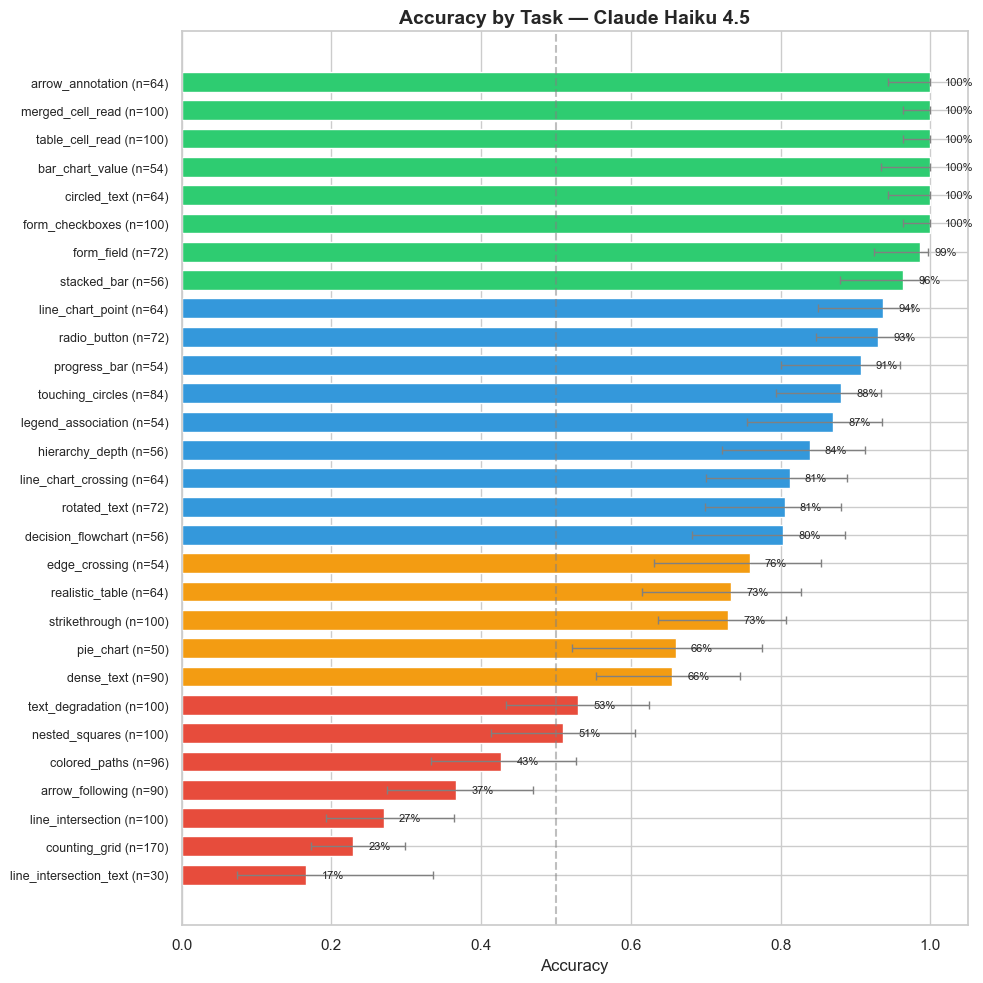


Task                          N     Acc           95% CI
--------------------------------------------------------
line_intersection_text       30  16.7% [7.3%, 33.6%]
counting_grid               170  22.9% [17.3%, 29.8%]
line_intersection           100  27.0% [19.3%, 36.4%]
arrow_following              90  36.7% [27.4%, 47.0%]
colored_paths                96  42.7% [33.3%, 52.7%]
nested_squares              100  51.0% [41.3%, 60.6%]
text_degradation            100  53.0% [43.3%, 62.5%]
dense_text                   90  65.6% [55.3%, 74.6%]
pie_chart                    50  66.0% [52.2%, 77.6%]
strikethrough               100  73.0% [63.6%, 80.7%]
realistic_table              64  73.4% [61.5%, 82.7%]
edge_crossing                54  75.9% [63.1%, 85.4%]
decision_flowchart           56  80.4% [68.2%, 88.7%]
rotated_text                 72  80.6% [70.0%, 88.0%]
line_chart_crossing          64  81.2% [70.0%, 88.9%]
hierarchy_depth              56  83.9% [72.2%, 91.3%]
legend_association    

In [23]:
# Accuracy by task with Wilson CIs
task_stats = df.groupby("task_name").agg(
    n=("correct", "count"),
    n_correct=("correct", lambda x: x.astype(bool).sum()),
).reset_index()
task_stats["accuracy"] = task_stats["n_correct"] / task_stats["n"]
task_stats["ci"] = task_stats.apply(lambda r: wilson_ci(r["n_correct"], r["n"]), axis=1)
task_stats["ci_lo"] = task_stats["ci"].apply(lambda x: x[0])
task_stats["ci_hi"] = task_stats["ci"].apply(lambda x: x[1])
task_stats = task_stats.sort_values("accuracy", ascending=True)

# Color by accuracy tier
def tier_color(acc):
    if acc >= 0.95: return "#2ecc71"
    if acc >= 0.80: return "#3498db"
    if acc >= 0.60: return "#f39c12"
    return "#e74c3c"

colors = task_stats["accuracy"].apply(tier_color).tolist()

fig, ax = plt.subplots(figsize=(10, 10))
y_pos = range(len(task_stats))
bars = ax.barh(y_pos, task_stats["accuracy"], color=colors, edgecolor="white", height=0.7)

# Error bars for CIs (clamp to non-negative)
xerr_lo = (task_stats["accuracy"] - task_stats["ci_lo"]).clip(lower=0)
xerr_hi = (task_stats["ci_hi"] - task_stats["accuracy"]).clip(lower=0)
ax.errorbar(task_stats["accuracy"].values, list(y_pos), xerr=[xerr_lo.values, xerr_hi.values],
            fmt="none", ecolor="gray", capsize=3, linewidth=1)

ax.set_yticks(list(y_pos))
ax.set_yticklabels([f"{r['task_name']} (n={r['n']})" for _, r in task_stats.iterrows()], fontsize=9)
ax.set_xlabel("Accuracy", fontsize=12)
ax.set_title("Accuracy by Task — Claude Haiku 4.5", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.axvline(x=0.5, color="gray", linestyle="--", alpha=0.5)

# Add accuracy labels
for i, (_, r) in enumerate(task_stats.iterrows()):
    ax.text(r["accuracy"] + 0.02, i, f"{r['accuracy']:.0%}", va="center", fontsize=8)

fig.tight_layout()
plt.show()

# Summary table
print(f"\n{'Task':<25} {'N':>5} {'Acc':>7} {'95% CI':>16}")
print("-" * 56)
for _, r in task_stats.iterrows():
    print(f"{r['task_name']:<25} {r['n']:>5} {r['accuracy']:>6.1%} [{r['ci_lo']:.1%}, {r['ci_hi']:.1%}]")
print("-" * 56)
total = len(df)
total_correct = df["correct"].astype(bool).sum()
lo, hi = wilson_ci(total_correct, total)
print(f"{'OVERALL':<25} {total:>5} {total_correct/total:>6.1%} [{lo:.1%}, {hi:.1%}]")

## 2. Accuracy by Category

Tasks grouped by their spec categories: Tables, Charts, Diagrams, Forms, Annotations, Text/OCR, Geometry.

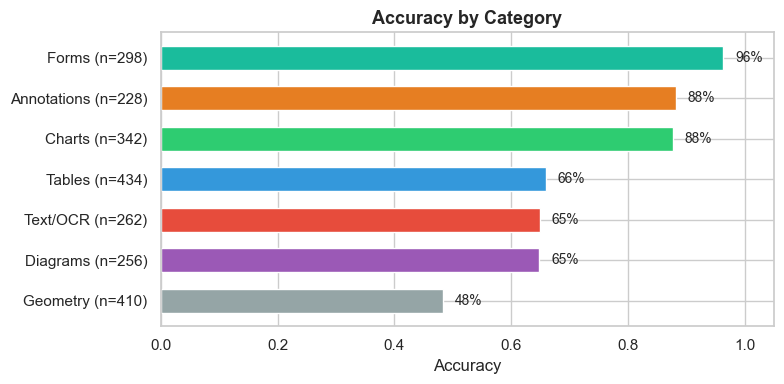


Geometry:
  colored_paths             43% (96 samples)
  line_intersection         27% (100 samples)
  line_intersection_text    17% (30 samples)
  nested_squares            51% (100 samples)
  touching_circles          88% (84 samples)

Diagrams:
  arrow_following           37% (90 samples)
  decision_flowchart        80% (56 samples)
  edge_crossing             76% (54 samples)
  hierarchy_depth           84% (56 samples)

Text/OCR:
  dense_text                66% (90 samples)
  rotated_text              81% (72 samples)
  text_degradation          53% (100 samples)

Tables:
  counting_grid             23% (170 samples)
  merged_cell_read          100% (100 samples)
  realistic_table           73% (64 samples)
  table_cell_read           100% (100 samples)

Charts:
  bar_chart_value           100% (54 samples)
  legend_association        87% (54 samples)
  line_chart_crossing       81% (64 samples)
  line_chart_point          94% (64 samples)
  pie_chart                 66% (50 samp

In [24]:
TASK_CATEGORIES = {
    "counting_grid": "Tables", "table_cell_read": "Tables",
    "realistic_table": "Tables", "merged_cell_read": "Tables",
    "line_chart_crossing": "Charts", "bar_chart_value": "Charts",
    "line_chart_point": "Charts", "legend_association": "Charts",
    "pie_chart": "Charts", "stacked_bar": "Charts",
    "arrow_following": "Diagrams", "decision_flowchart": "Diagrams",
    "edge_crossing": "Diagrams", "hierarchy_depth": "Diagrams",
    "form_checkboxes": "Forms", "radio_button": "Forms",
    "form_field": "Forms", "progress_bar": "Forms",
    "circled_text": "Annotations", "arrow_annotation": "Annotations",
    "strikethrough": "Annotations",
    "text_degradation": "Text/OCR", "rotated_text": "Text/OCR",
    "dense_text": "Text/OCR",
    "line_intersection": "Geometry", "touching_circles": "Geometry",
    "nested_squares": "Geometry", "colored_paths": "Geometry",
    "line_intersection_text": "Geometry",
}

df["category"] = df["task_name"].map(TASK_CATEGORIES).fillna("Other")

cat_stats = df.groupby("category").agg(
    n=("correct", "count"),
    n_correct=("correct", lambda x: x.astype(bool).sum()),
).reset_index()
cat_stats["accuracy"] = cat_stats["n_correct"] / cat_stats["n"]
cat_stats = cat_stats.sort_values("accuracy", ascending=True)

cat_colors = {
    "Tables": "#3498db", "Charts": "#2ecc71", "Diagrams": "#9b59b6",
    "Forms": "#1abc9c", "Annotations": "#e67e22", "Text/OCR": "#e74c3c",
    "Geometry": "#95a5a6",
}

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(range(len(cat_stats)), cat_stats["accuracy"],
               color=[cat_colors.get(c, "gray") for c in cat_stats["category"]],
               height=0.6, edgecolor="white")
ax.set_yticks(range(len(cat_stats)))
ax.set_yticklabels([f"{r['category']} (n={r['n']})" for _, r in cat_stats.iterrows()])
ax.set_xlabel("Accuracy")
ax.set_title("Accuracy by Category", fontsize=13, fontweight="bold")
ax.set_xlim(0, 1.05)

for i, (_, r) in enumerate(cat_stats.iterrows()):
    ax.text(r["accuracy"] + 0.02, i, f"{r['accuracy']:.0%}", va="center", fontsize=10)

fig.tight_layout()
plt.show()

# Per-category task breakdown
for cat in cat_stats.sort_values("accuracy")["category"]:
    cat_df = df[df["category"] == cat]
    print(f"\n{cat}:")
    for task in sorted(cat_df["task_name"].unique()):
        t_df = cat_df[cat_df["task_name"] == task]
        acc = t_df["correct"].astype(bool).mean()
        print(f"  {task:<25} {acc:.0%} ({len(t_df)} samples)")

## 3. Parameter Sensitivity

How accuracy varies with key parameters (font_size, resolution, complexity, etc.).

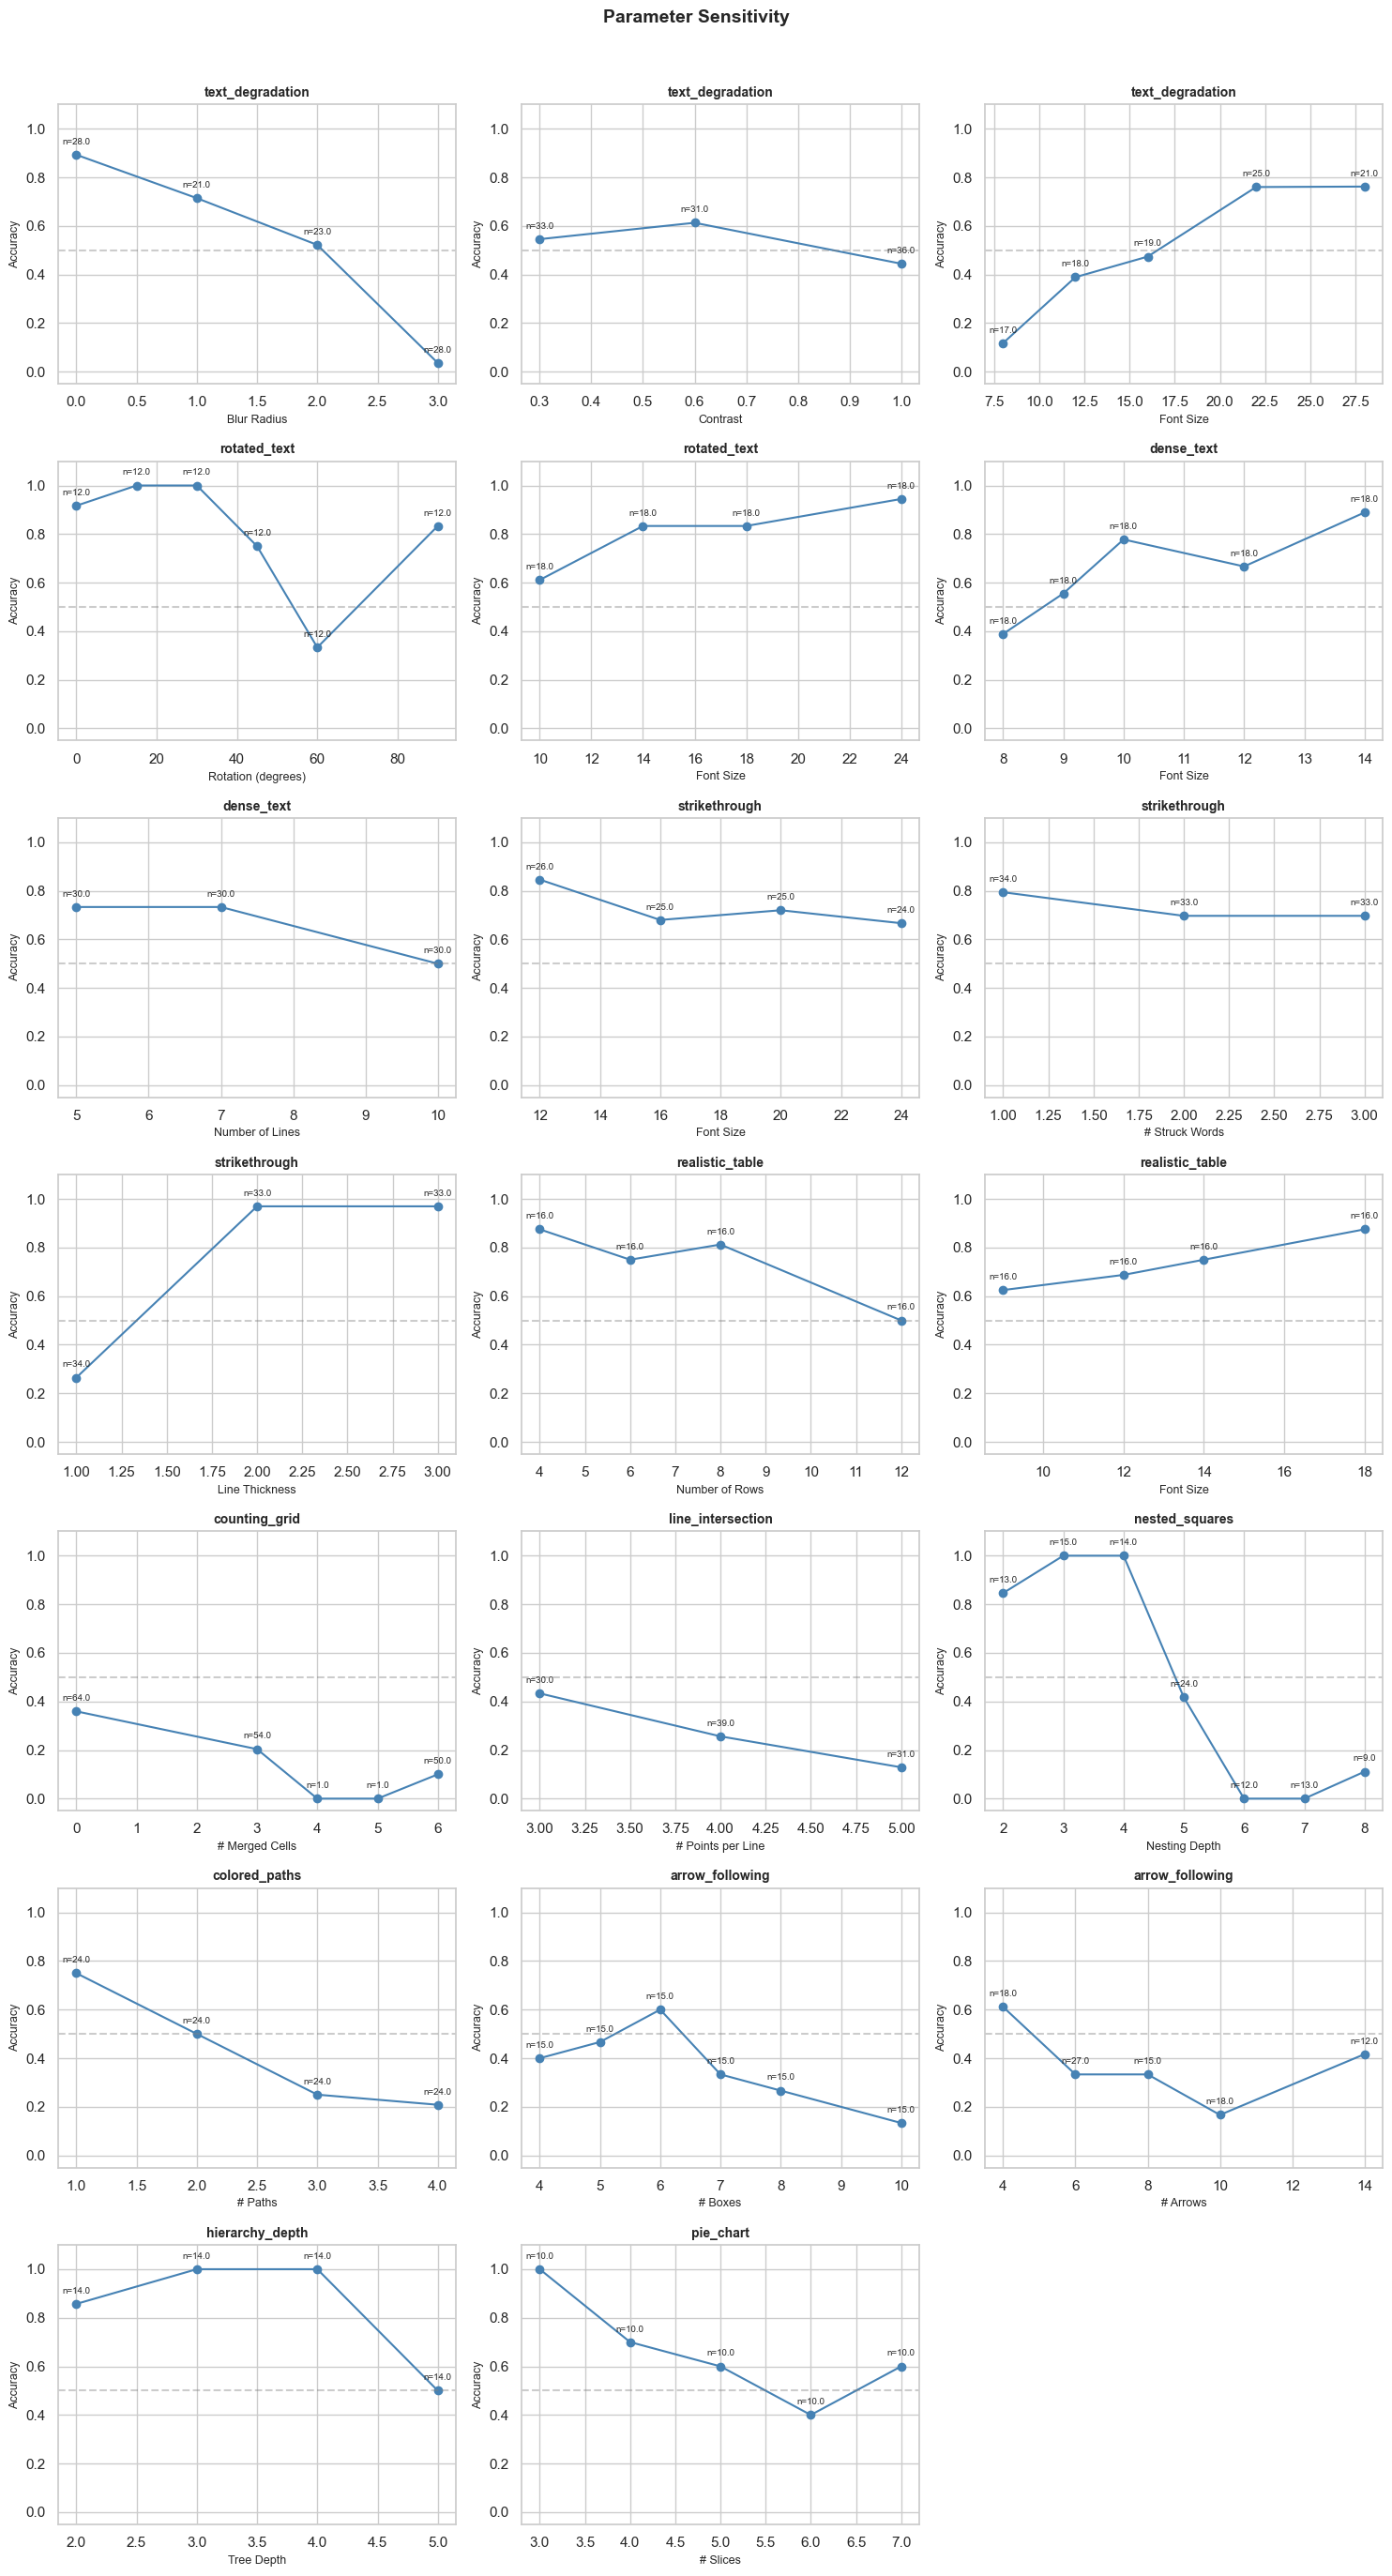

In [25]:
# Parameter sensitivity plots for key tasks

def plot_param_sensitivity(task_name, param_col, xlabel=None):
    """Plot accuracy vs a parameter for a single task."""
    t_df = df[df["task_name"] == task_name].copy()
    if param_col not in t_df.columns or t_df[param_col].isna().all():
        print(f"  {task_name}: param {param_col} not found")
        return None
    grouped = t_df.groupby(param_col).agg(
        n=("correct", "count"),
        acc=("correct", lambda x: x.astype(bool).mean()),
    ).reset_index()
    if len(grouped) < 2:
        return None
    return grouped, xlabel or param_col.replace("p_", "")

# Define interesting param sweeps per task
SENSITIVITY_PARAMS = [
    ("text_degradation", "p_blur_radius", "Blur Radius"),
    ("text_degradation", "p_contrast", "Contrast"),
    ("text_degradation", "p_font_size", "Font Size"),
    ("rotated_text", "p_rotation", "Rotation (degrees)"),
    ("rotated_text", "p_font_size", "Font Size"),
    ("dense_text", "p_font_size", "Font Size"),
    ("dense_text", "p_n_lines", "Number of Lines"),
    ("strikethrough", "p_font_size", "Font Size"),
    ("strikethrough", "p_n_struck", "# Struck Words"),
    ("strikethrough", "p_line_thickness", "Line Thickness"),
    ("realistic_table", "p_n_rows", "Number of Rows"),
    ("realistic_table", "p_font_size", "Font Size"),
    ("counting_grid", "p_n_merged", "# Merged Cells"),
    ("line_intersection", "p_n_points", "# Points per Line"),
    ("nested_squares", "p_depth", "Nesting Depth"),
    ("colored_paths", "p_n_paths", "# Paths"),
    ("arrow_following", "p_n_boxes", "# Boxes"),
    ("arrow_following", "p_n_arrows", "# Arrows"),
    ("hierarchy_depth", "p_depth", "Tree Depth"),
    ("pie_chart", "p_n_slices", "# Slices"),
]

# Filter to those with data
valid = []
for task, param, label in SENSITIVITY_PARAMS:
    if task in df["task_name"].values and param in df.columns:
        t_df = df[(df["task_name"] == task) & df[param].notna()]
        if t_df[param].nunique() >= 2:
            valid.append((task, param, label))

n_plots = len(valid)
n_cols = 3
n_rows = (n_plots + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
axes = axes.flatten()

for idx, (task, param, label) in enumerate(valid):
    ax = axes[idx]
    t_df = df[(df["task_name"] == task) & df[param].notna()]
    grouped = t_df.groupby(param).agg(
        n=("correct", "count"),
        acc=("correct", lambda x: x.astype(bool).mean()),
    ).reset_index()

    ax.plot(grouped[param], grouped["acc"], "o-", color="steelblue", markersize=6)
    for _, r in grouped.iterrows():
        ax.annotate(f"n={r['n']}", (r[param], r["acc"]),
                    textcoords="offset points", xytext=(0, 8), fontsize=7, ha="center")
    ax.set_xlabel(label, fontsize=9)
    ax.set_ylabel("Accuracy", fontsize=9)
    ax.set_title(f"{task}", fontsize=10, fontweight="bold")
    ax.set_ylim(-0.05, 1.1)
    ax.axhline(y=0.5, color="gray", linestyle="--", alpha=0.4)

for idx in range(n_plots, len(axes)):
    axes[idx].set_visible(False)

fig.suptitle("Parameter Sensitivity", fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 4. Clutter Tax — Geometric Primitives vs Business Context

Does adding business context (labels, colors, chart decorations) help or hurt perception?  
Matched pairs test the same perceptual primitive in clean vs business settings.

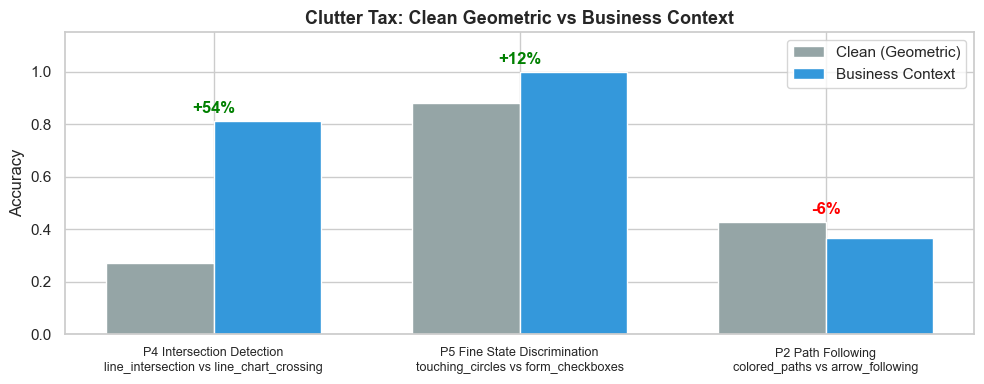


Primitive                      Clean                     Business                   Clean Acc    Biz Acc      Gap
----------------------------------------------------------------------------------------------------------------
P4 Intersection Detection      line_intersection         line_chart_crossing           27.0%     81.2%  +54.2%
P5 Fine State Discrimination   touching_circles          form_checkboxes               88.1%    100.0%  +11.9%
P2 Path Following              colored_paths             arrow_following               42.7%     36.7%   -6.0%


In [26]:
CLUTTER_PAIRS = [
    ("line_intersection", "line_chart_crossing", "P4 Intersection Detection"),
    ("touching_circles", "form_checkboxes", "P5 Fine State Discrimination"),
    ("colored_paths", "arrow_following", "P2 Path Following"),
]

pair_data = []
for clean, biz, primitive in CLUTTER_PAIRS:
    clean_df = df[df["task_name"] == clean]
    biz_df = df[df["task_name"] == biz]
    if len(clean_df) == 0 or len(biz_df) == 0:
        continue
    clean_acc = clean_df["correct"].astype(bool).mean()
    biz_acc = biz_df["correct"].astype(bool).mean()
    pair_data.append({
        "primitive": primitive,
        "clean_task": clean, "biz_task": biz,
        "clean_acc": clean_acc, "biz_acc": biz_acc,
        "gap": biz_acc - clean_acc,
    })

pair_df = pd.DataFrame(pair_data)

# Grouped bar chart
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(pair_df))
w = 0.35
bars1 = ax.bar(x - w/2, pair_df["clean_acc"], w, label="Clean (Geometric)", color="#95a5a6")
bars2 = ax.bar(x + w/2, pair_df["biz_acc"], w, label="Business Context", color="#3498db")

ax.set_xticks(x)
ax.set_xticklabels([f"{r['primitive']}\n{r['clean_task']} vs {r['biz_task']}" for _, r in pair_df.iterrows()],
                   fontsize=9)
ax.set_ylabel("Accuracy")
ax.set_title("Clutter Tax: Clean Geometric vs Business Context", fontsize=13, fontweight="bold")
ax.set_ylim(0, 1.15)
ax.legend()

# Gap annotations
for i, (_, r) in enumerate(pair_df.iterrows()):
    gap_str = f"{r['gap']:+.0%}"
    color = "green" if r["gap"] > 0 else "red"
    y = max(r["clean_acc"], r["biz_acc"]) + 0.03
    ax.text(i, y, gap_str, ha="center", fontsize=12, fontweight="bold", color=color)

fig.tight_layout()
plt.show()

# Table
print(f"\n{'Primitive':<30} {'Clean':<25} {'Business':<25} {'Clean Acc':>10} {'Biz Acc':>10} {'Gap':>8}")
print("-" * 112)
for _, r in pair_df.iterrows():
    print(f"{r['primitive']:<30} {r['clean_task']:<25} {r['biz_task']:<25} {r['clean_acc']:>9.1%} {r['biz_acc']:>9.1%} {r['gap']:>+7.1%}")

## 5. Failure Gallery

View individual failure cases with images, model responses, and ground truth.  
Change `TASK` and `N` below to explore different tasks.

In [27]:
def show_failures(dataframe, title="Failures", n=8):
    """Display a grid of failure cases with images and annotations."""
    samples = dataframe.head(n)
    if len(samples) == 0:
        print("No failures to display.")
        return

    n_actual = len(samples)
    n_cols = min(4, n_actual)
    n_rows = (n_actual + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 6 * n_rows))
    if n_rows == 1 and n_cols == 1:
        axes = np.array([[axes]])
    elif n_rows == 1:
        axes = axes[np.newaxis, :]
    elif n_cols == 1:
        axes = axes[:, np.newaxis]

    for idx, (_, row) in enumerate(samples.iterrows()):
        r, c = divmod(idx, n_cols)
        ax = axes[r, c]

        img_path = row["image_path"]
        if Path(img_path).exists():
            img = mpimg.imread(img_path)
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Image not found", ha="center", va="center", transform=ax.transAxes)
        ax.axis("off")

        gt = str(row["ground_truth"]).replace("$", r"\$")
        pred = str(row.get("parsed_answer", "??")).replace("$", r"\$")
        response = str(row.get("raw_response", ""))[:150].replace("$", r"\$")

        caption = f"GT: {gt}  |  Pred: {pred}\n{response}"
        ax.set_title(f"{row['task_name']} ({row['sample_id'][:8]})", fontsize=9, fontweight="bold")
        ax.text(0.5, -0.02, caption, transform=ax.transAxes, fontsize=7,
                va="top", ha="center", wrap=True,
                bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.9))

    for idx in range(n_actual, n_rows * n_cols):
        r, c = divmod(idx, n_cols)
        axes[r, c].set_visible(False)

    fig.suptitle(title, fontsize=14, fontweight="bold")
    fig.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

In [ ]:
# === CONFIGURE THESE ===
TASK = "text_degradation"     # Change to any task name
N = 8                         # Number of failures to show
# =======================

gallery_df = failures[failures["task_name"] == TASK].copy()
show_failures(gallery_df, title=f"{TASK} failures ({len(gallery_df)} total)", n=N)

## 6. Top Failures Per Task

4 failure examples for each task that has failures, sorted by failure rate (worst first).

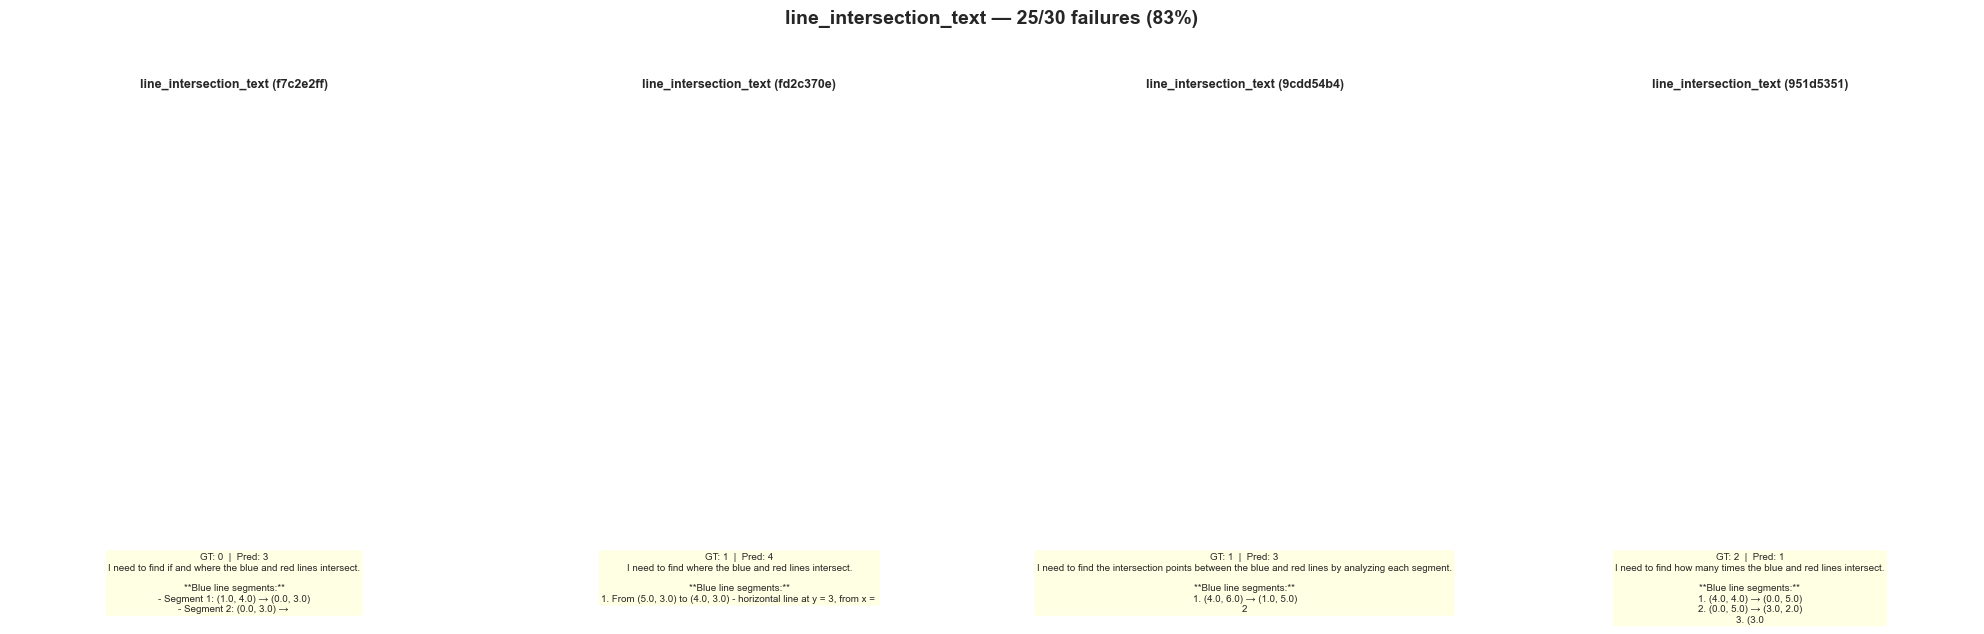

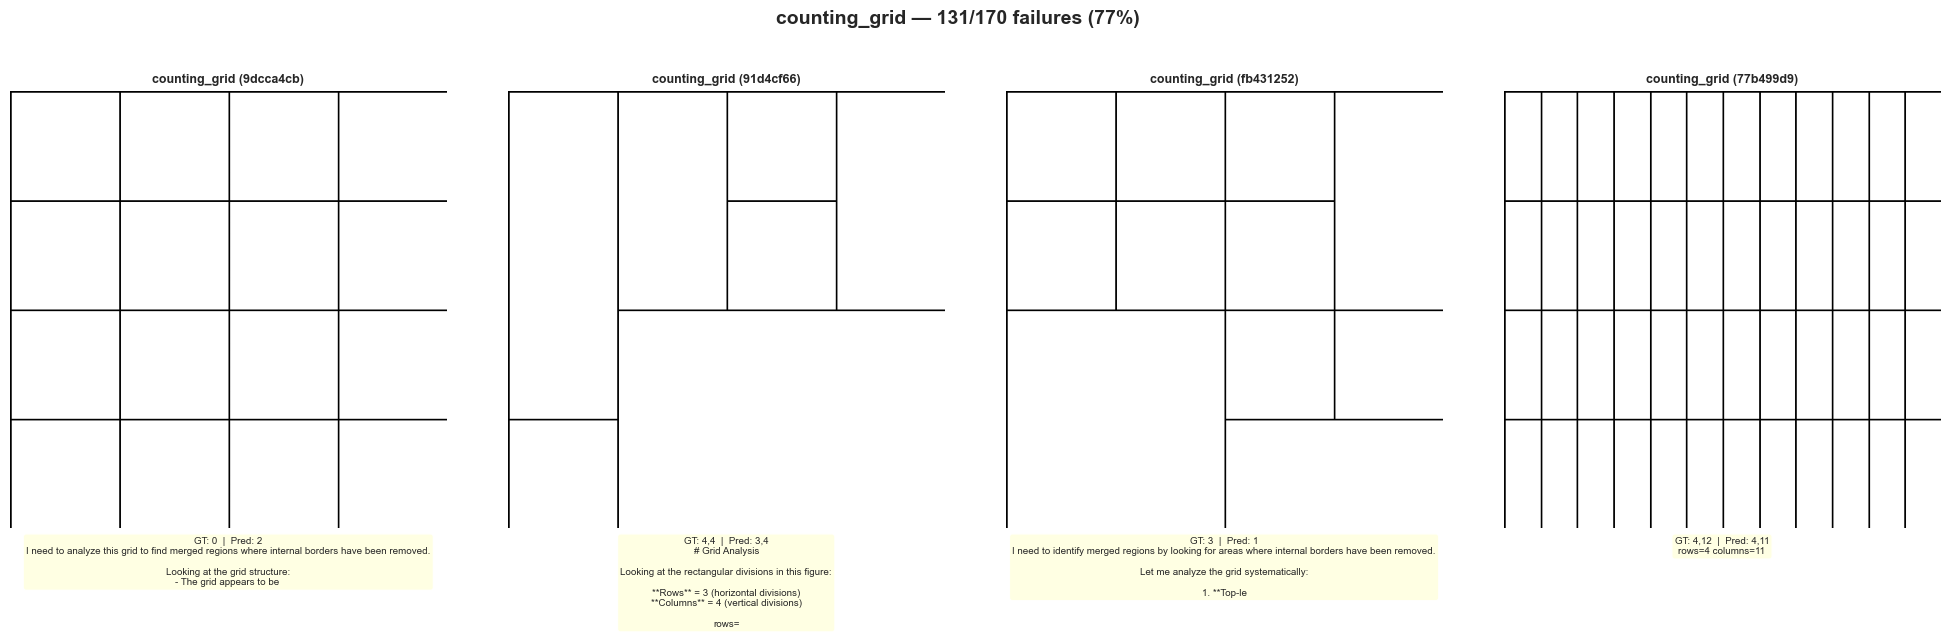

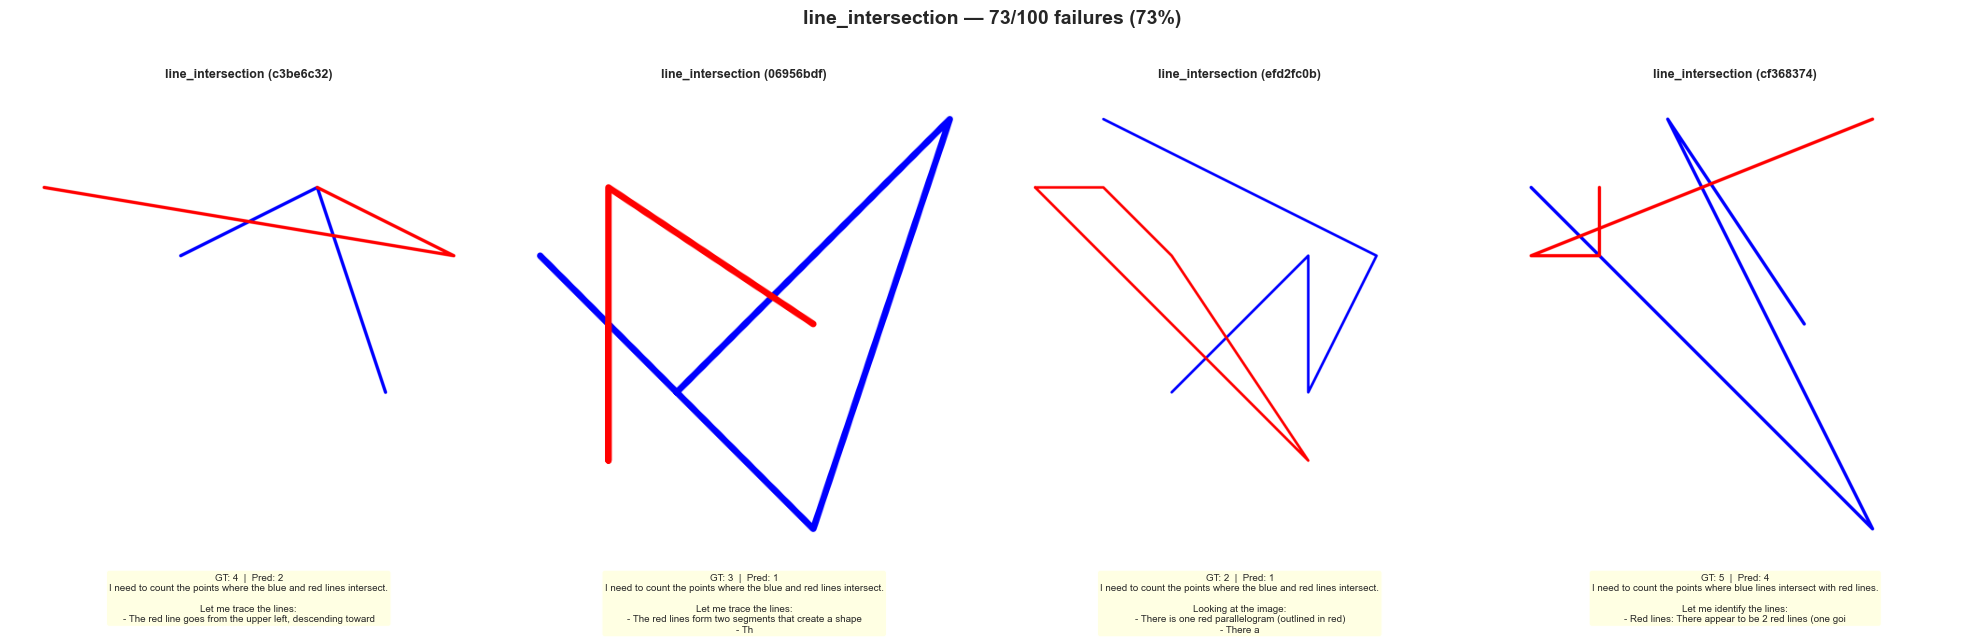

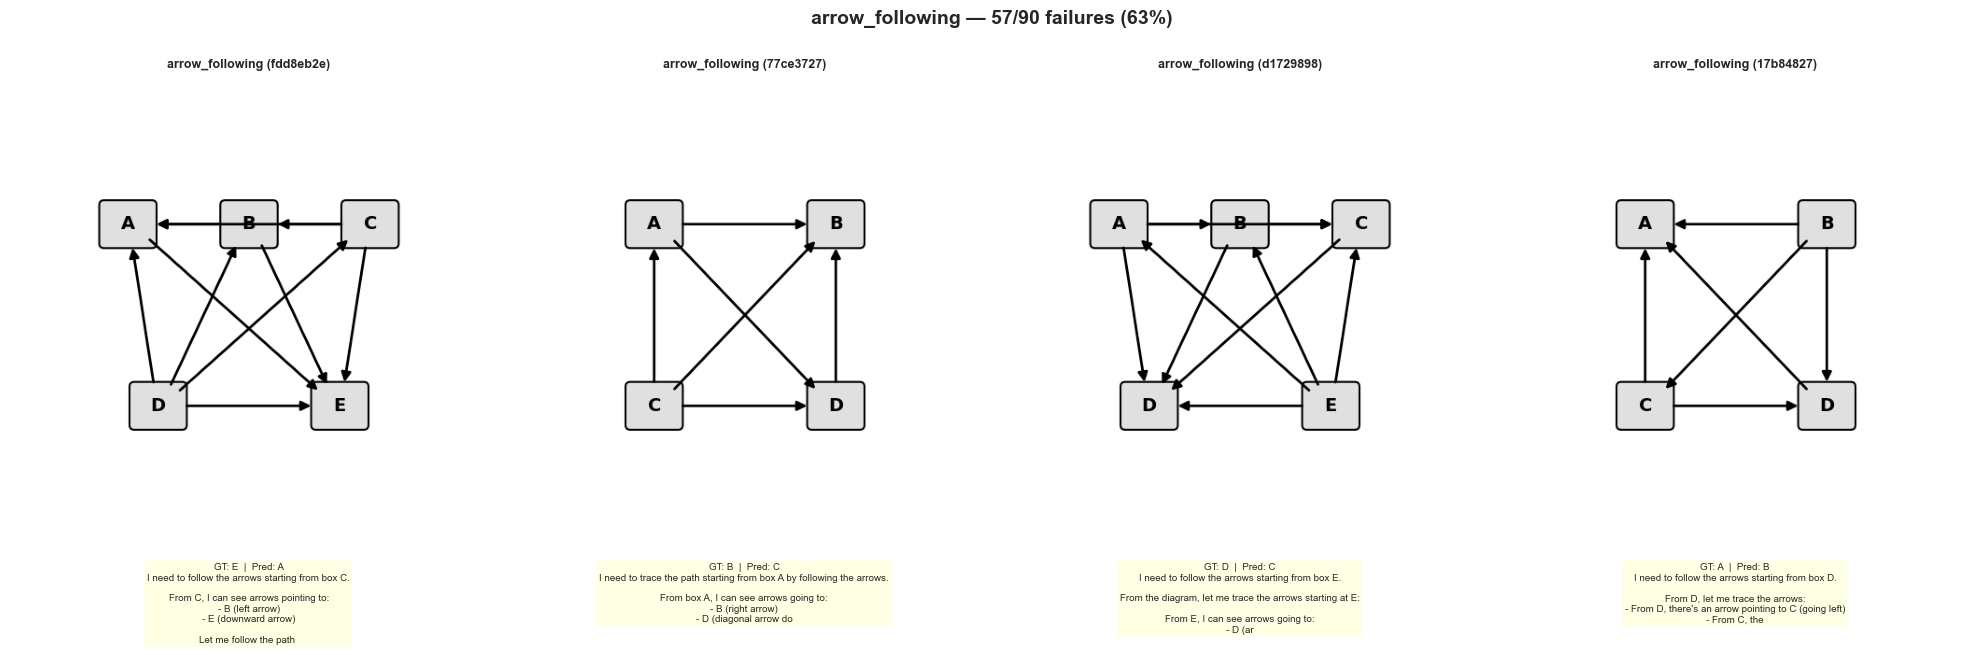

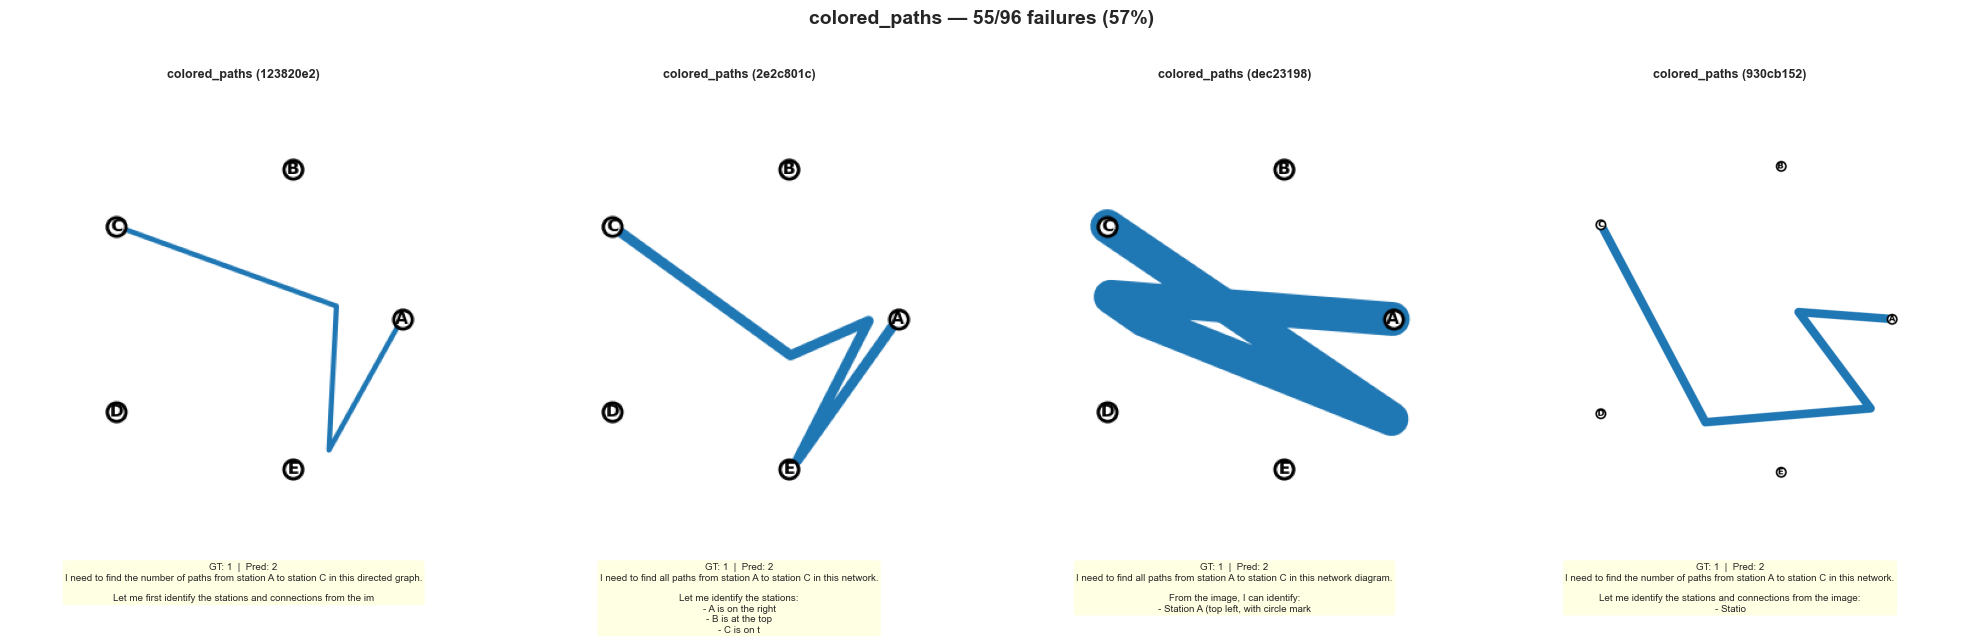

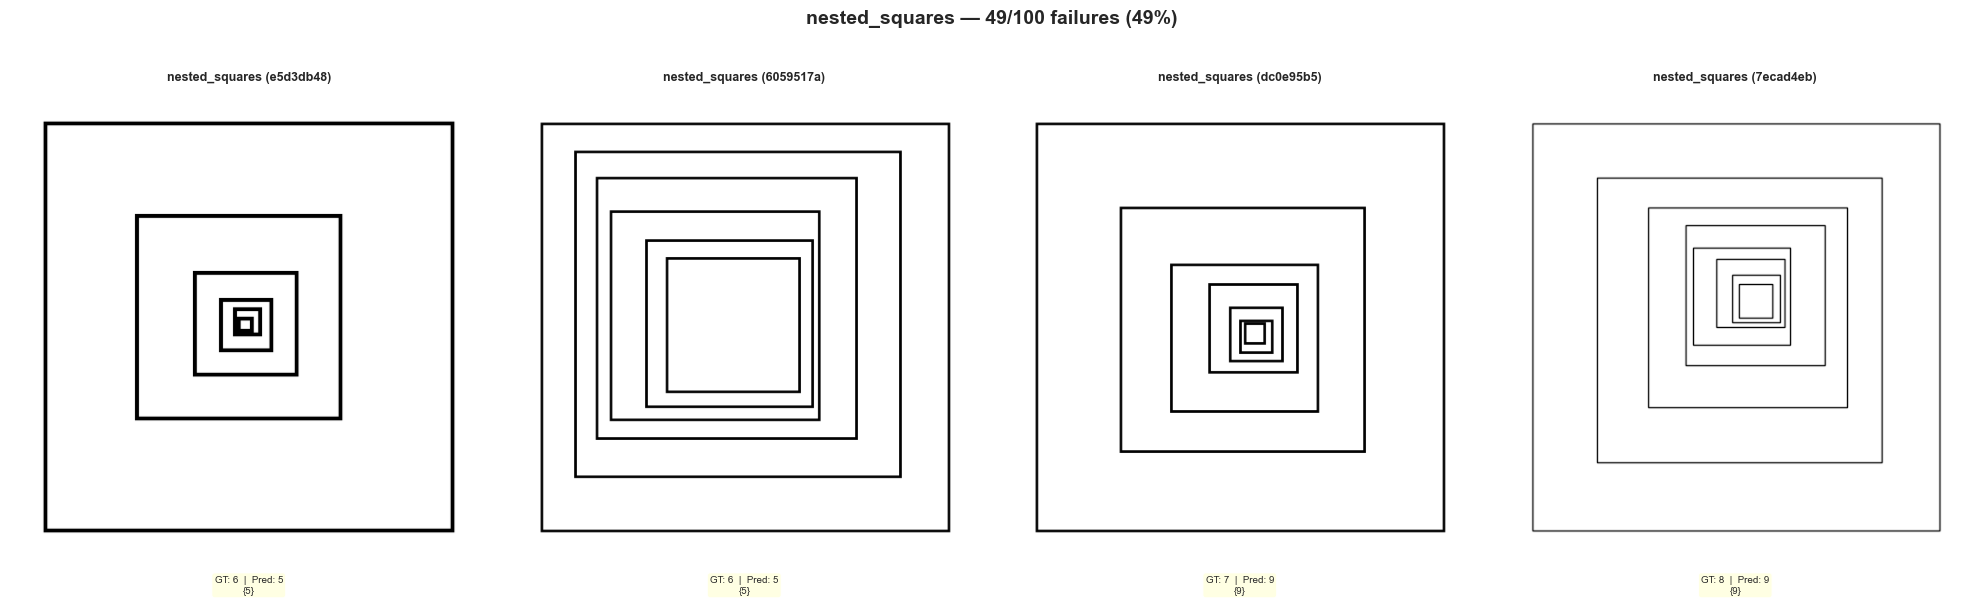

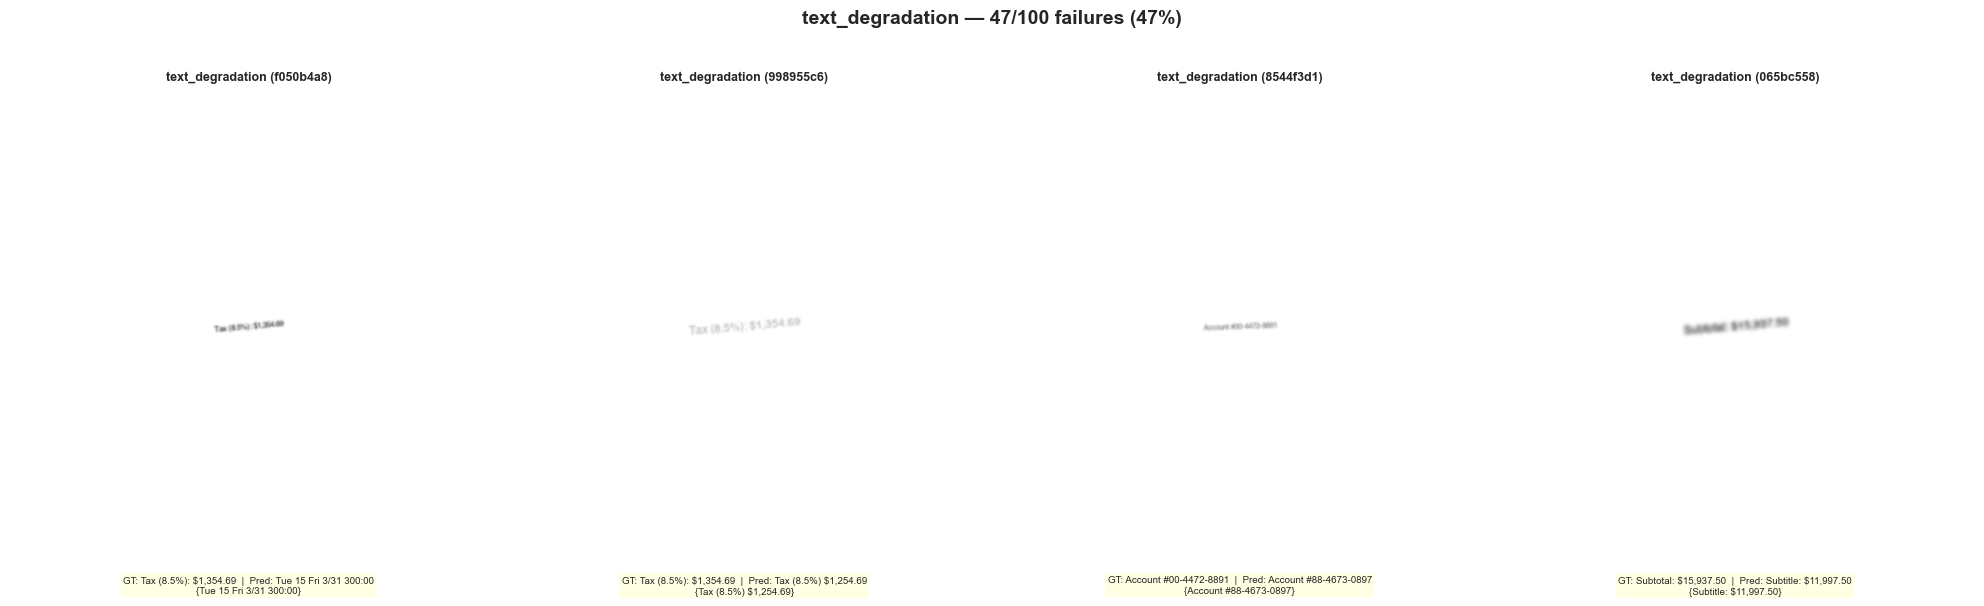

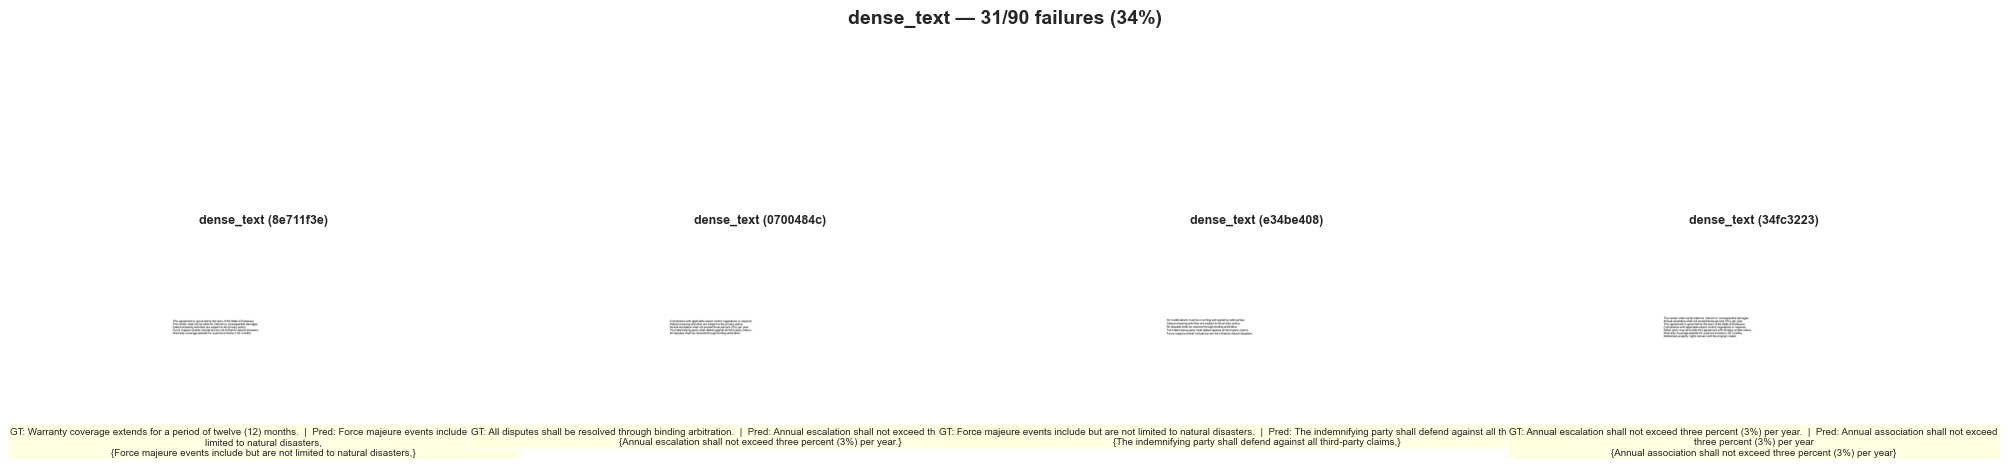

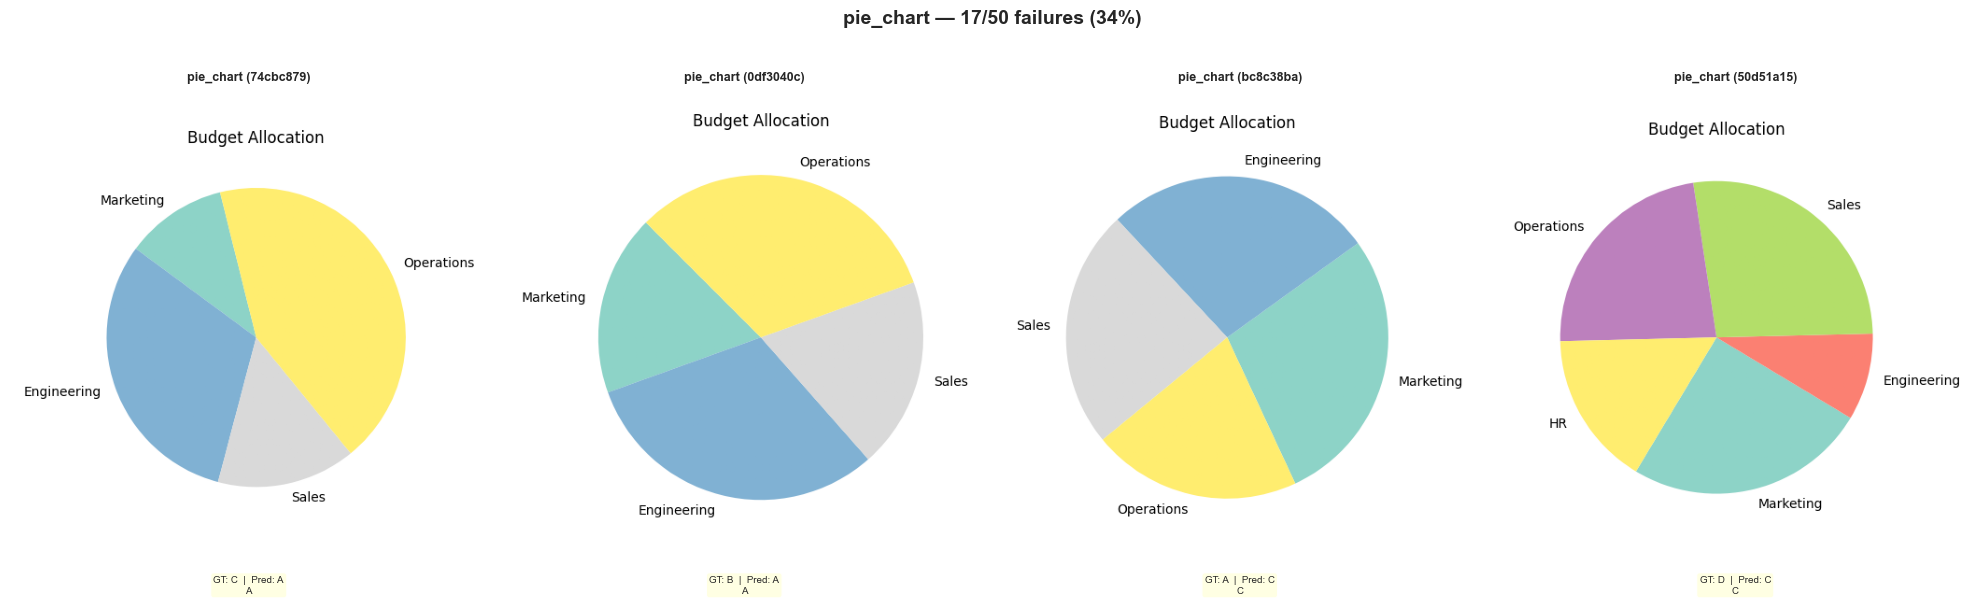

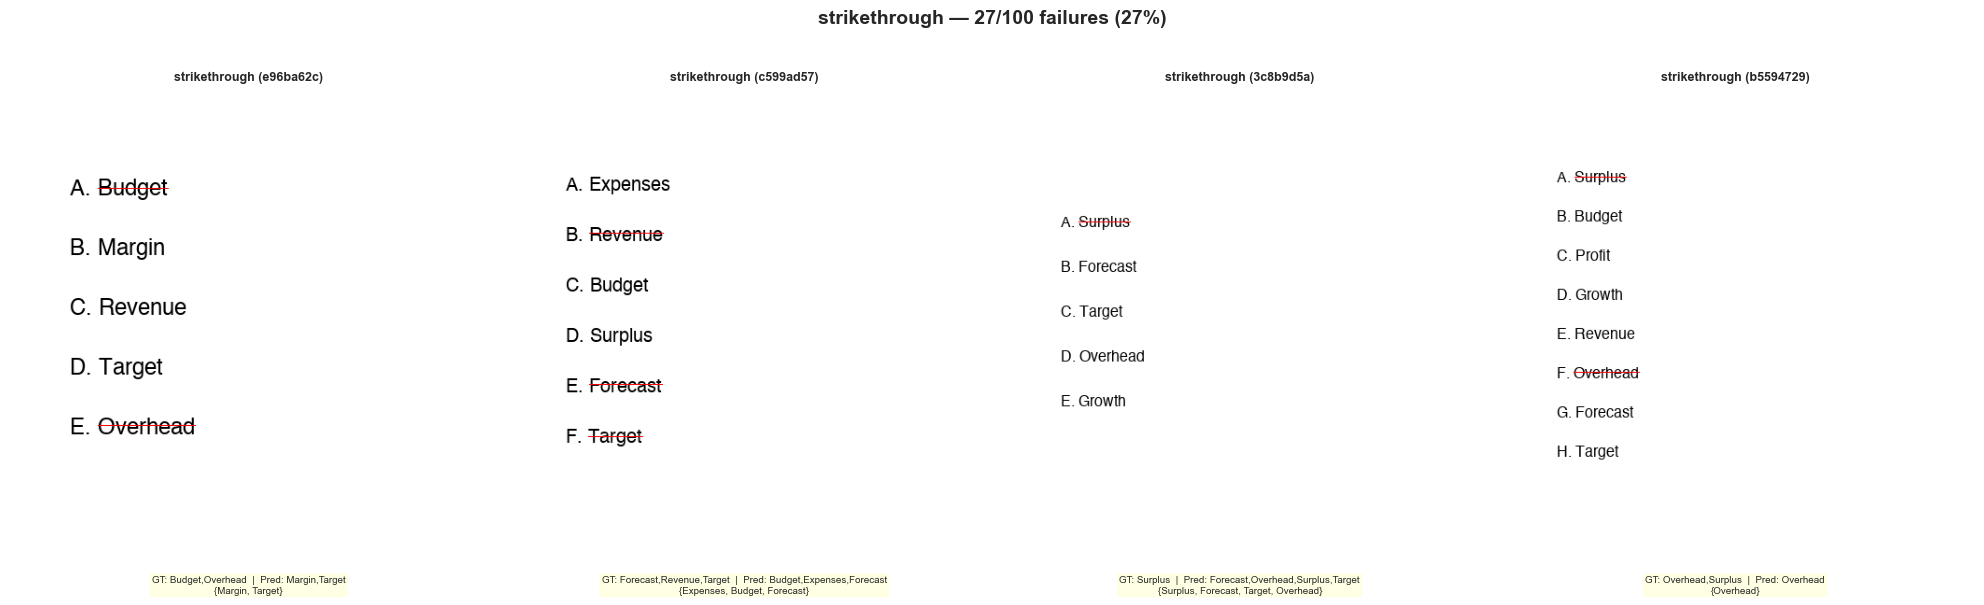

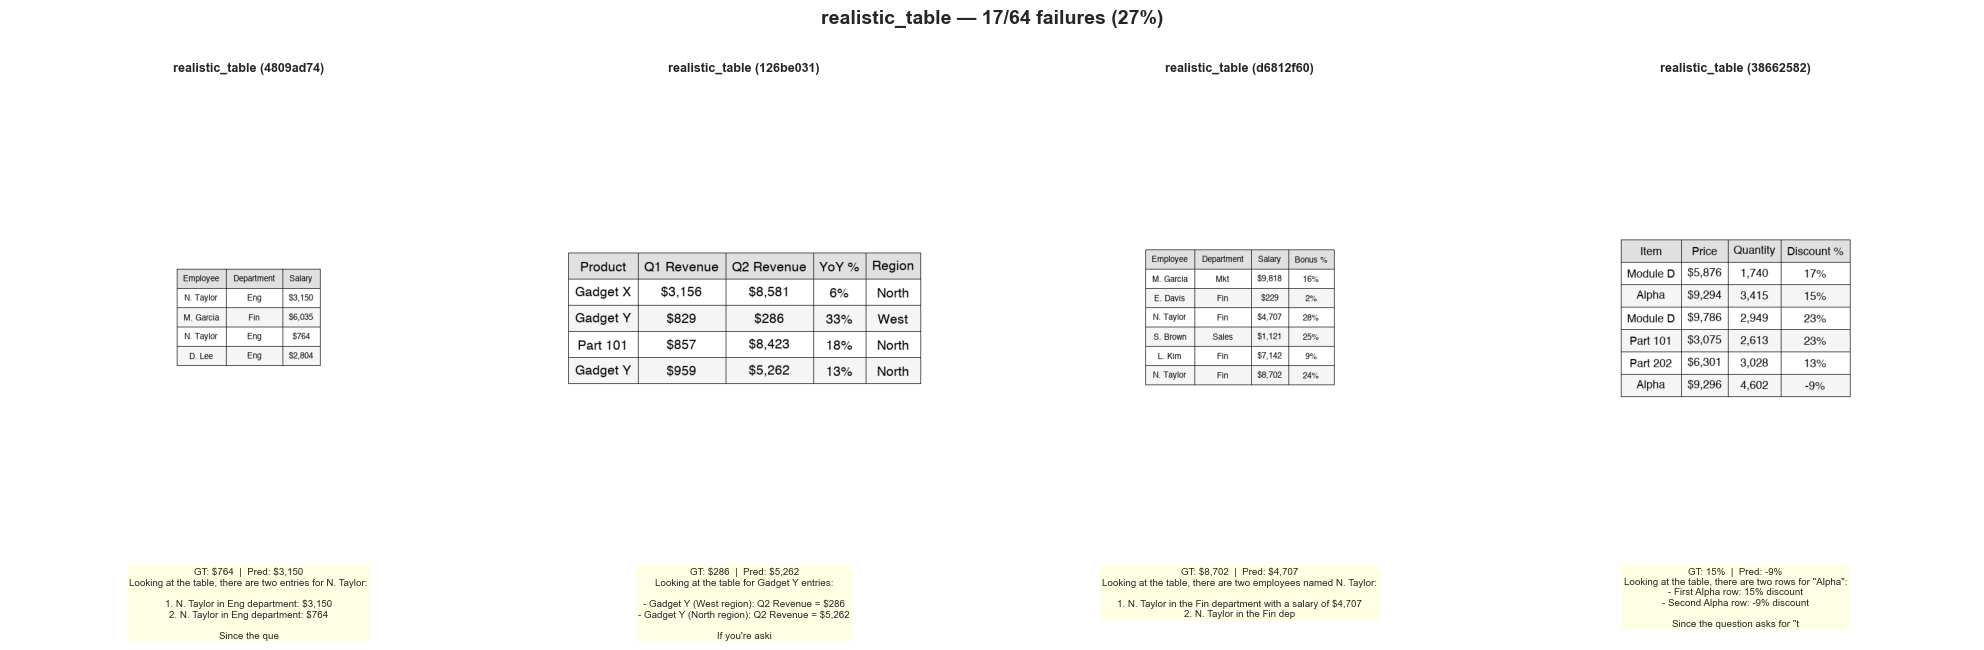

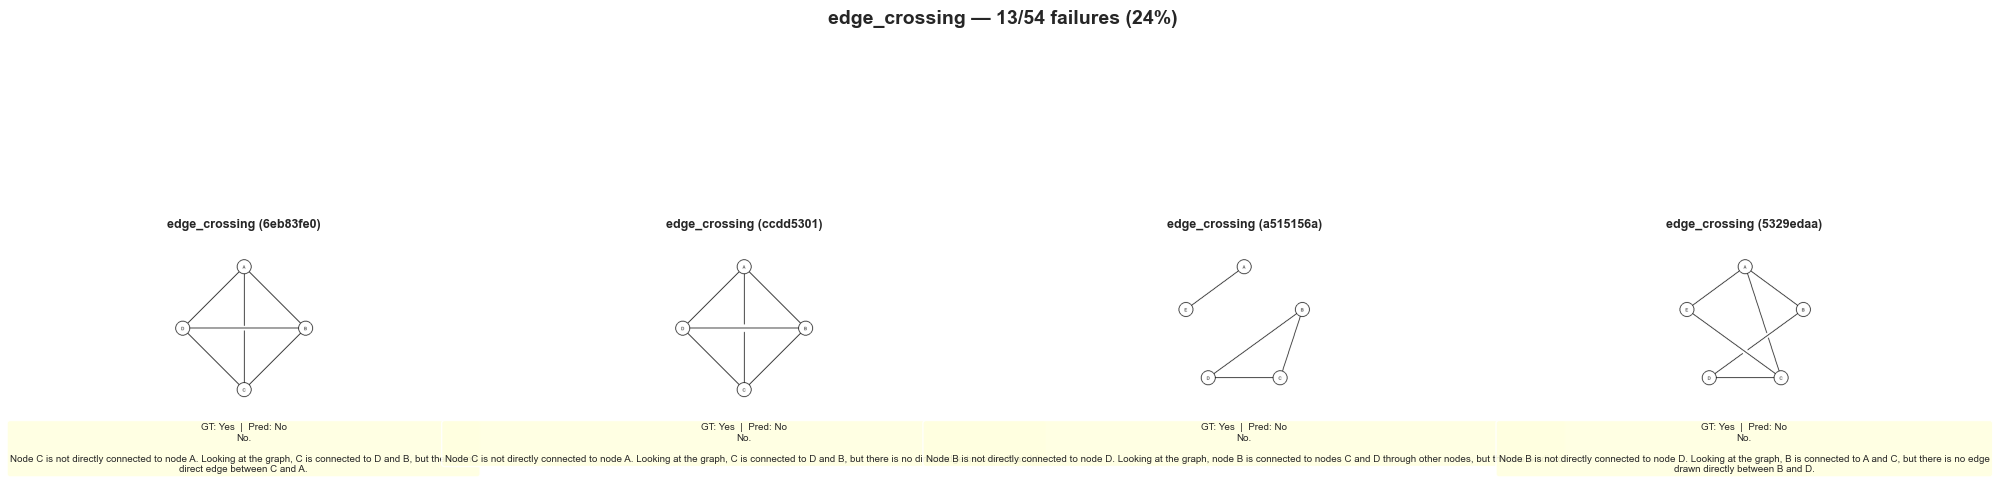

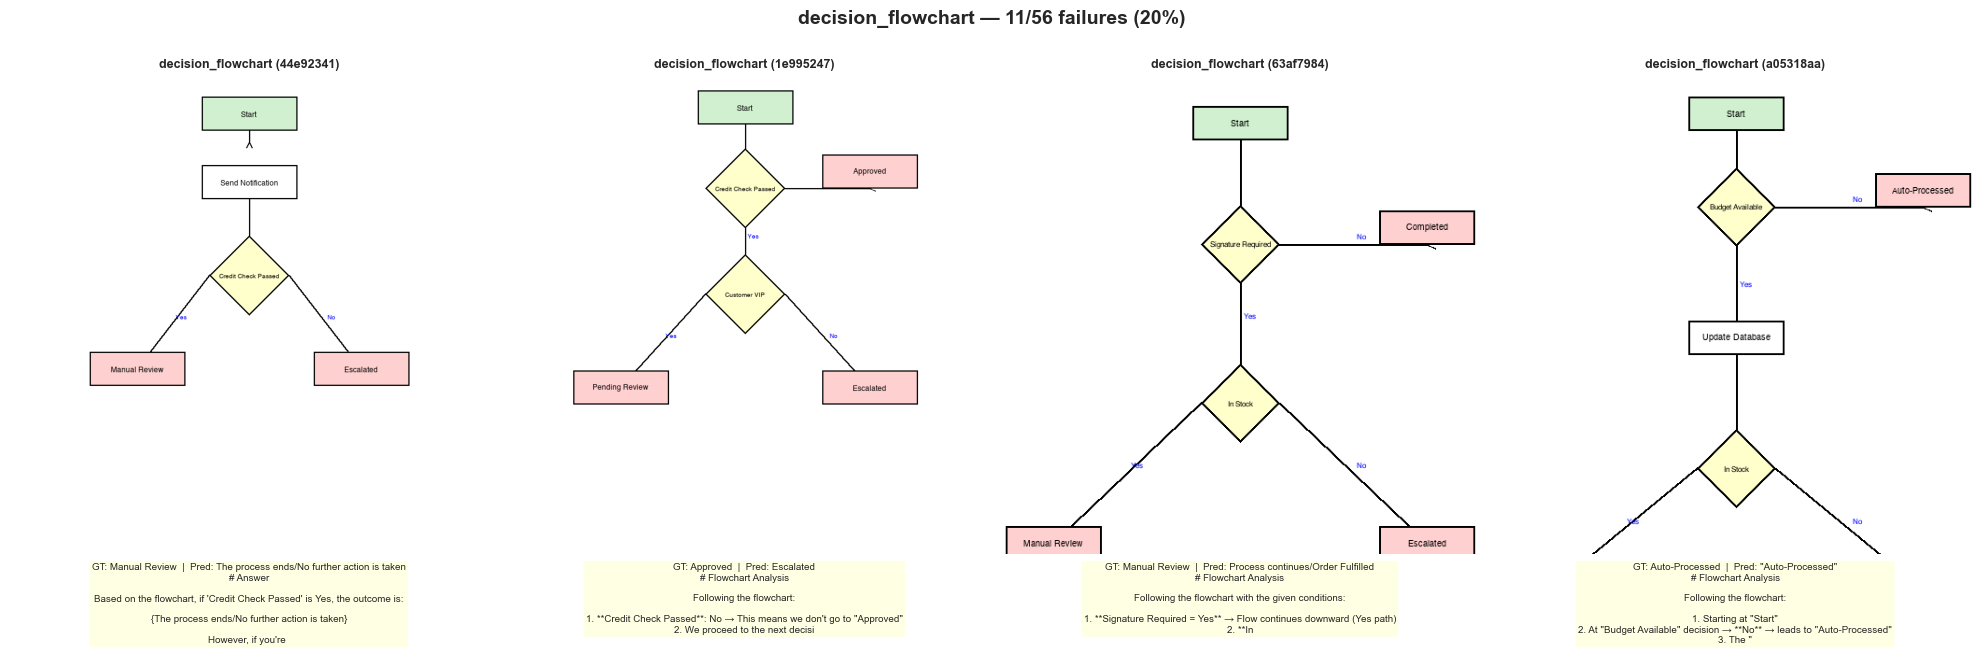

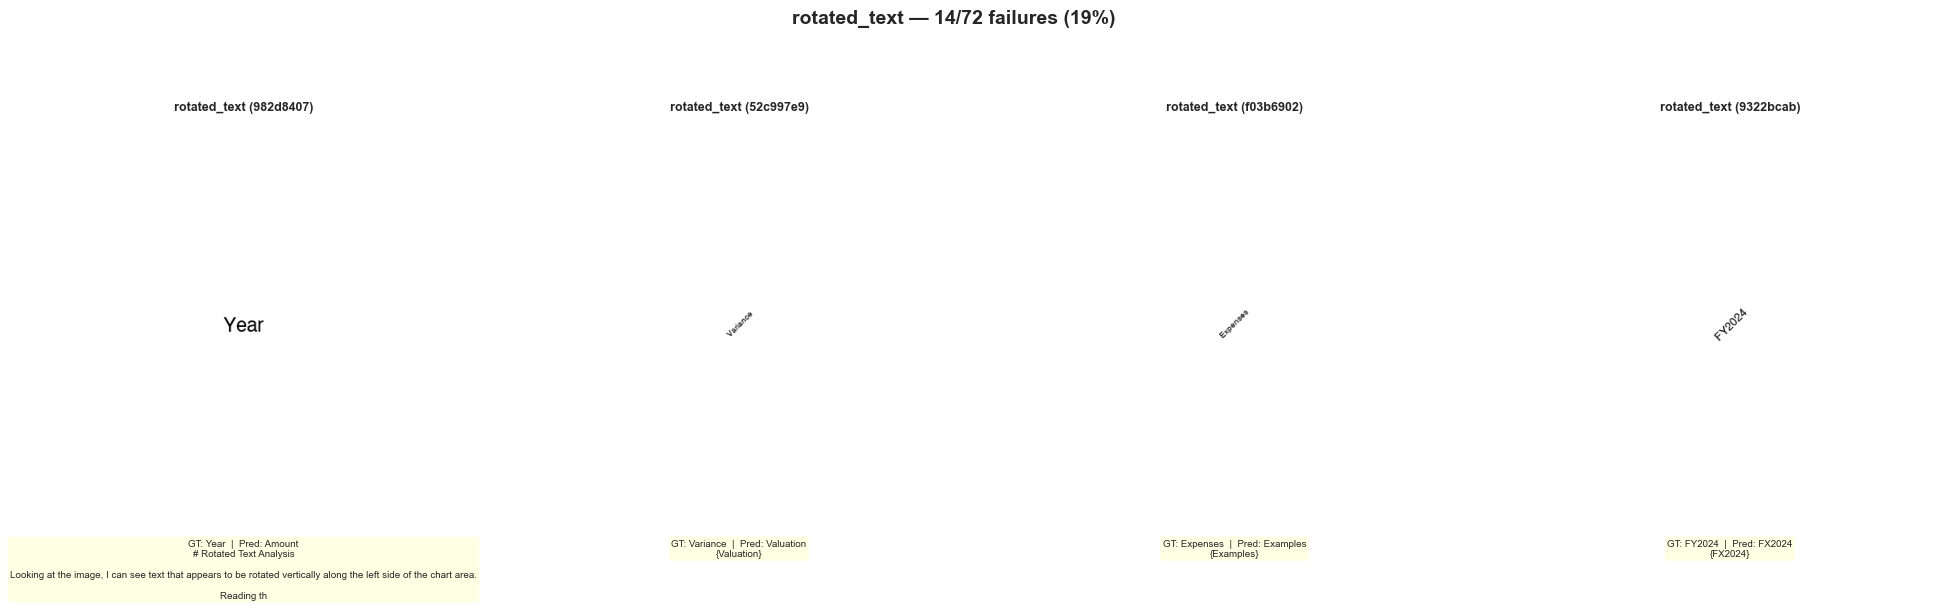

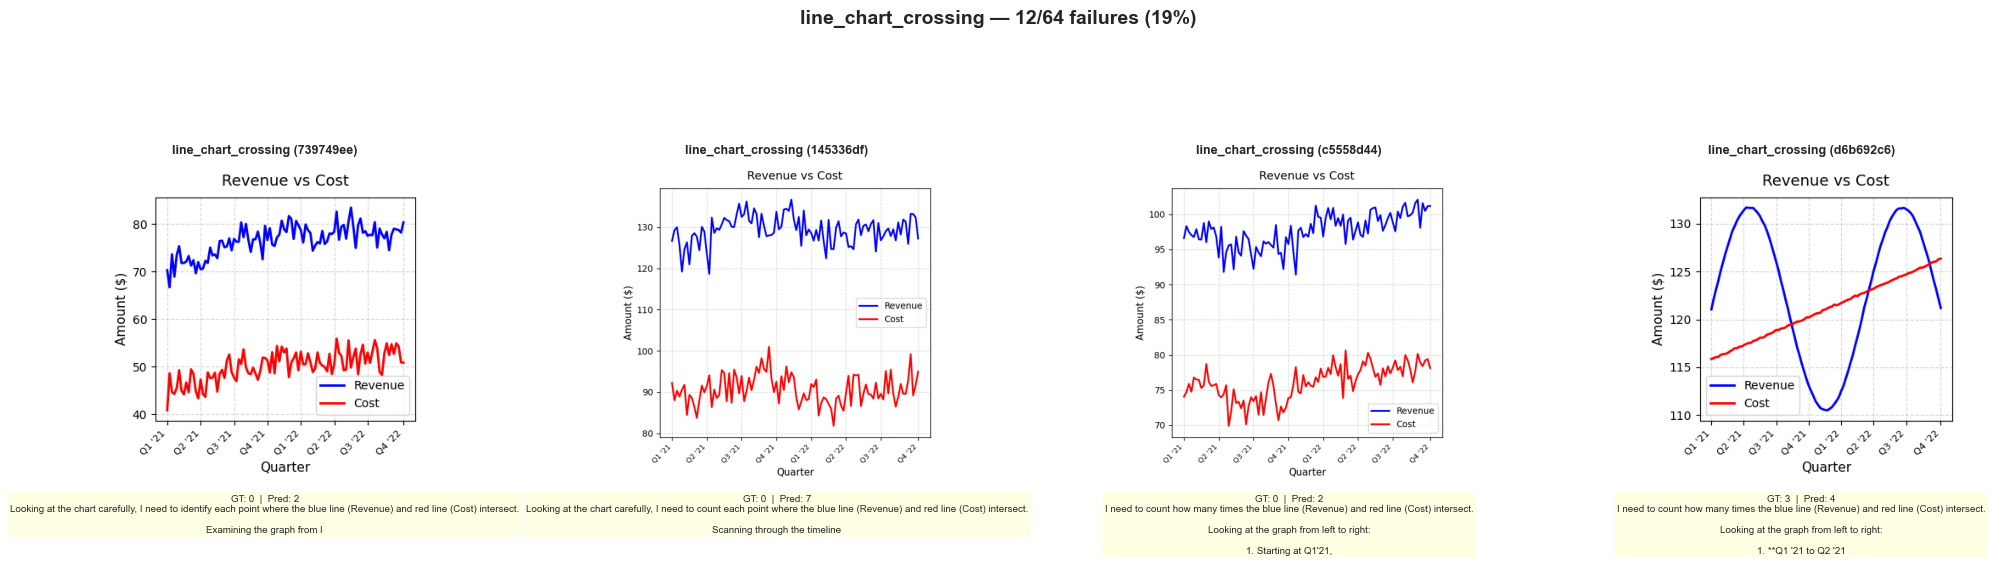

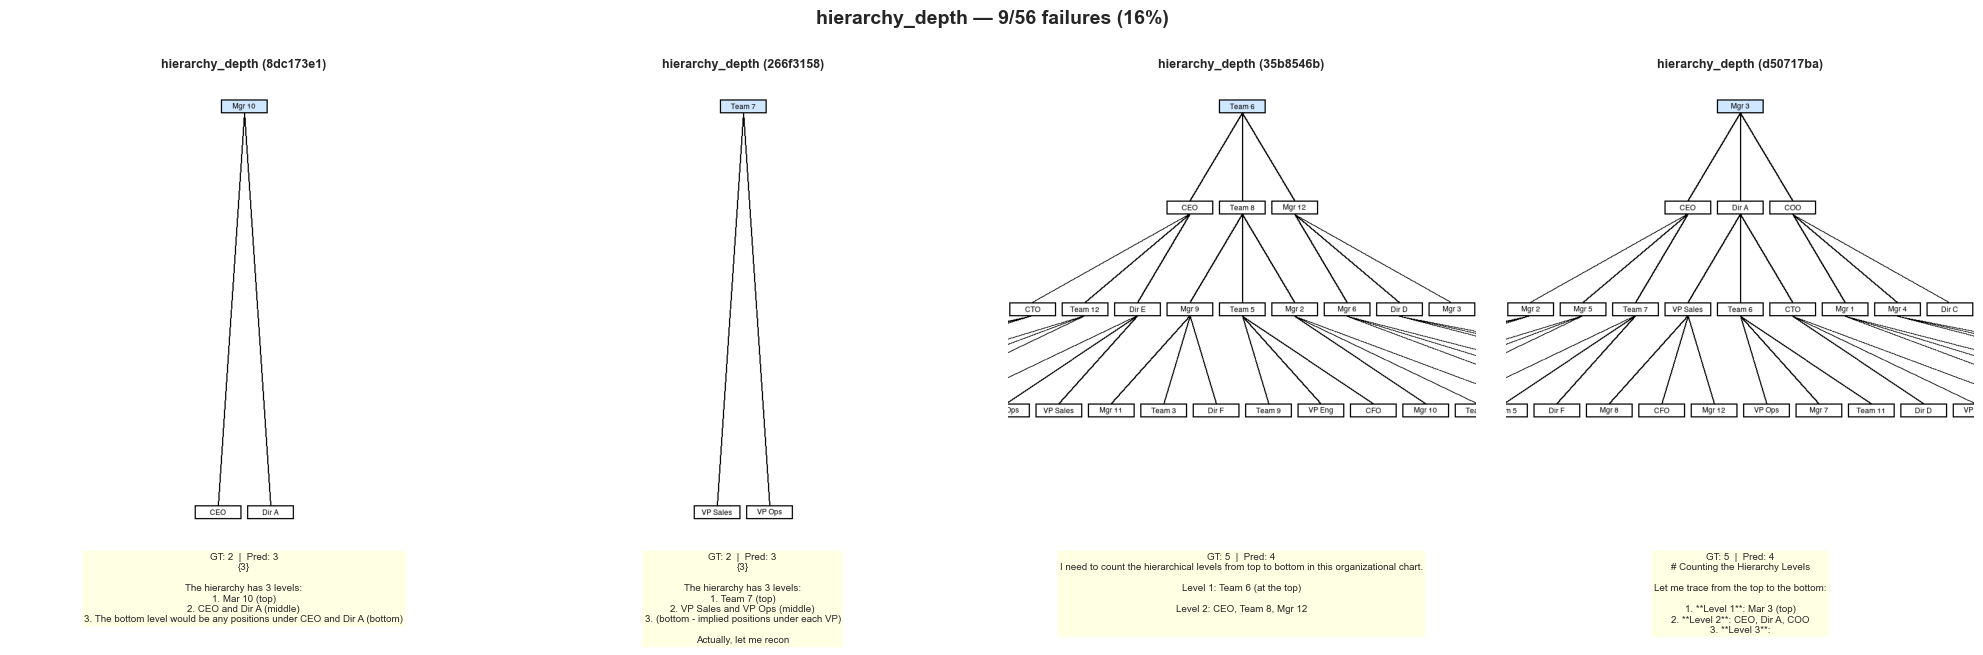

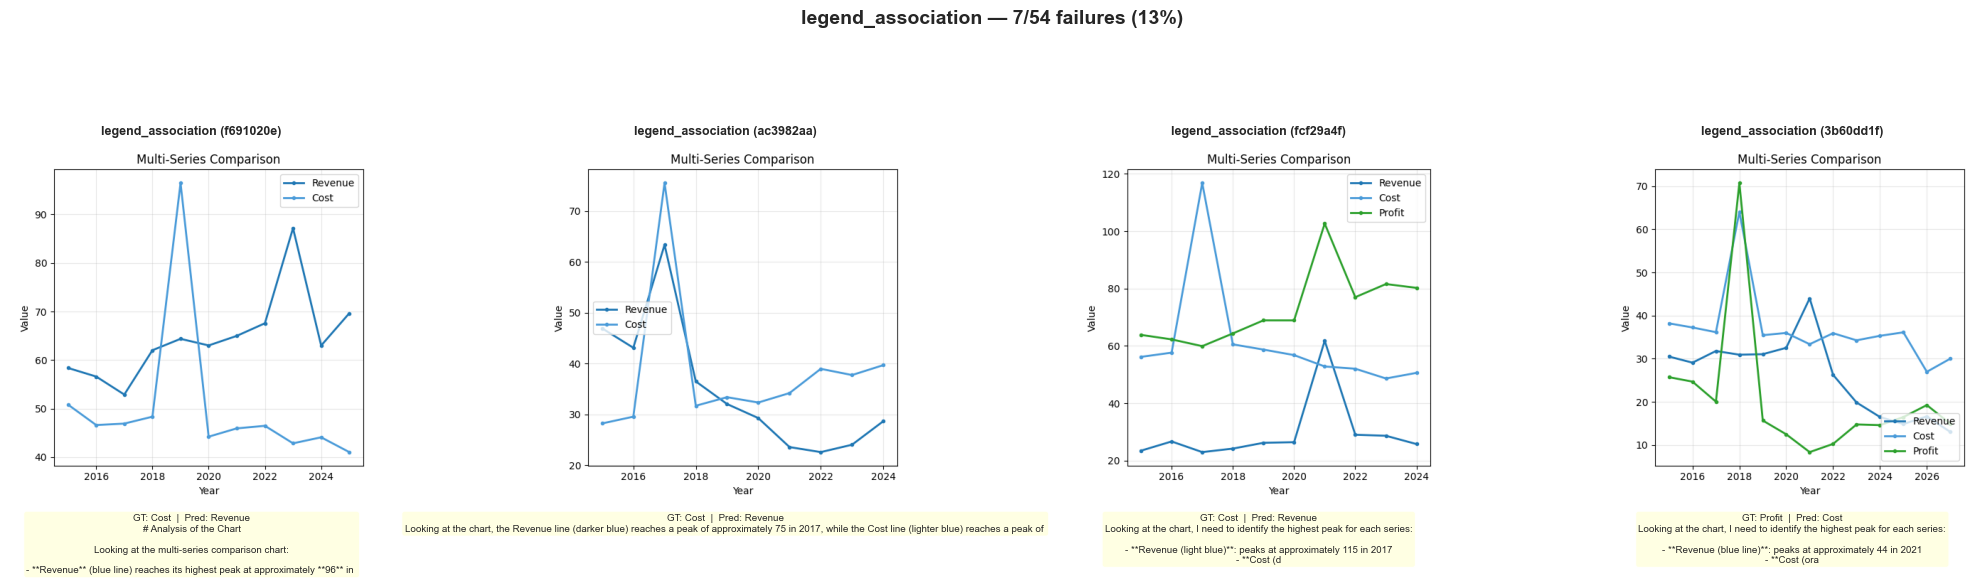

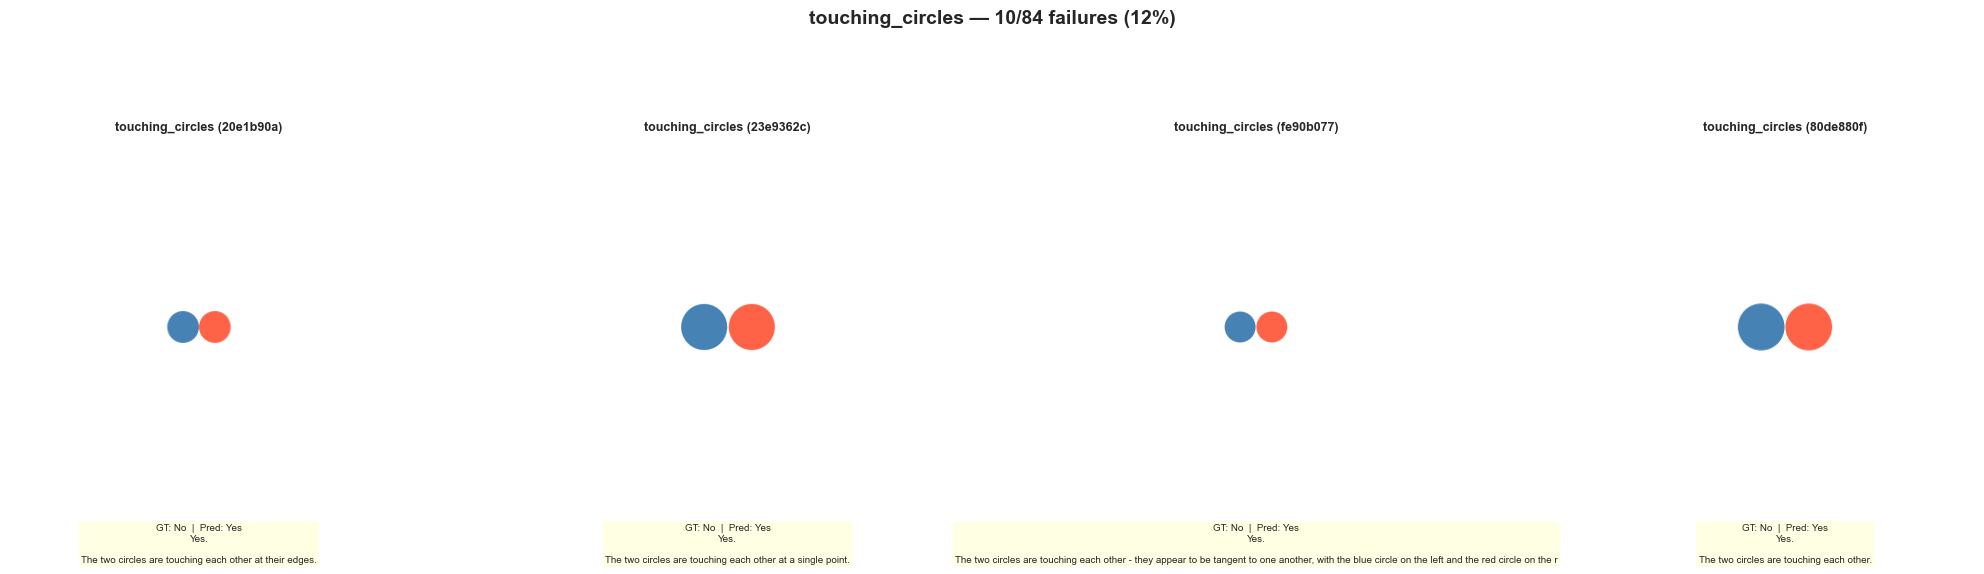

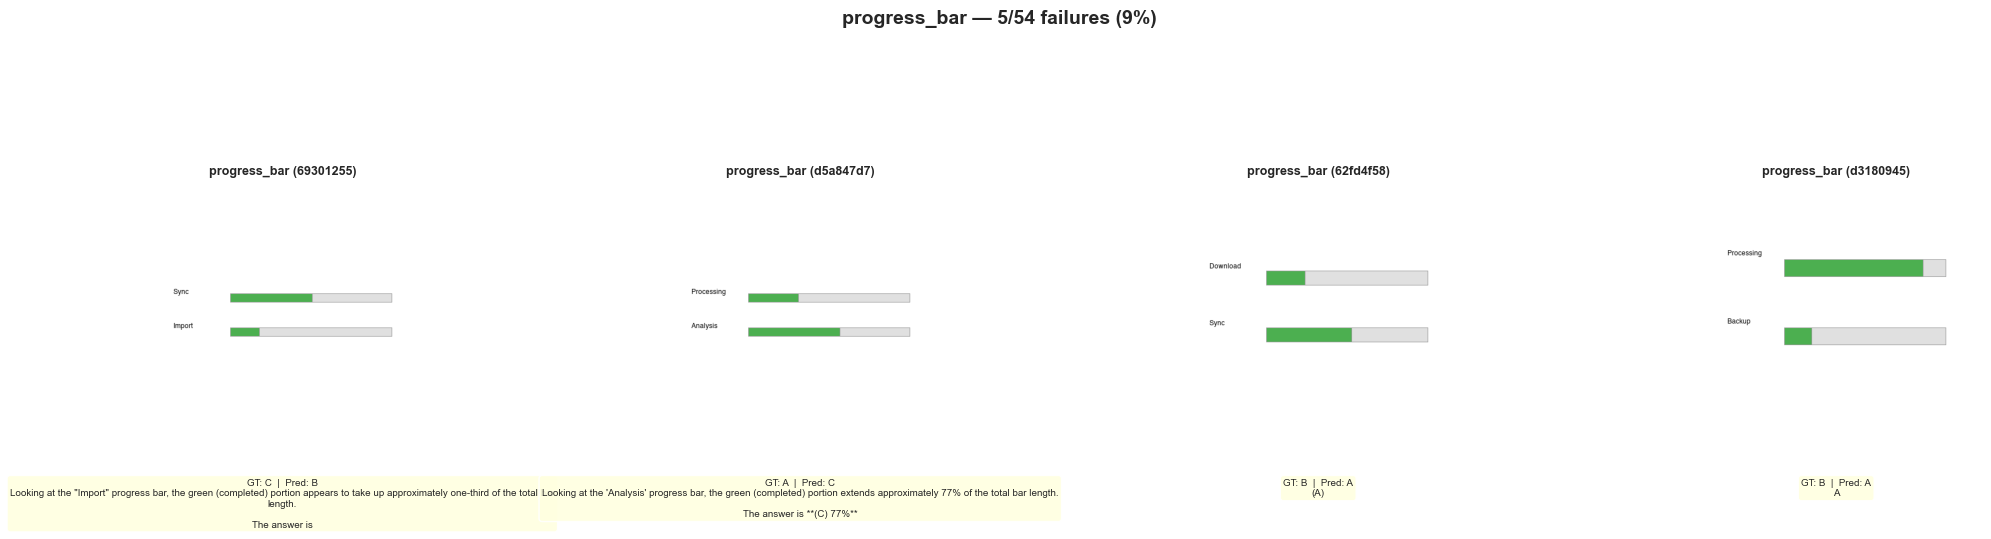

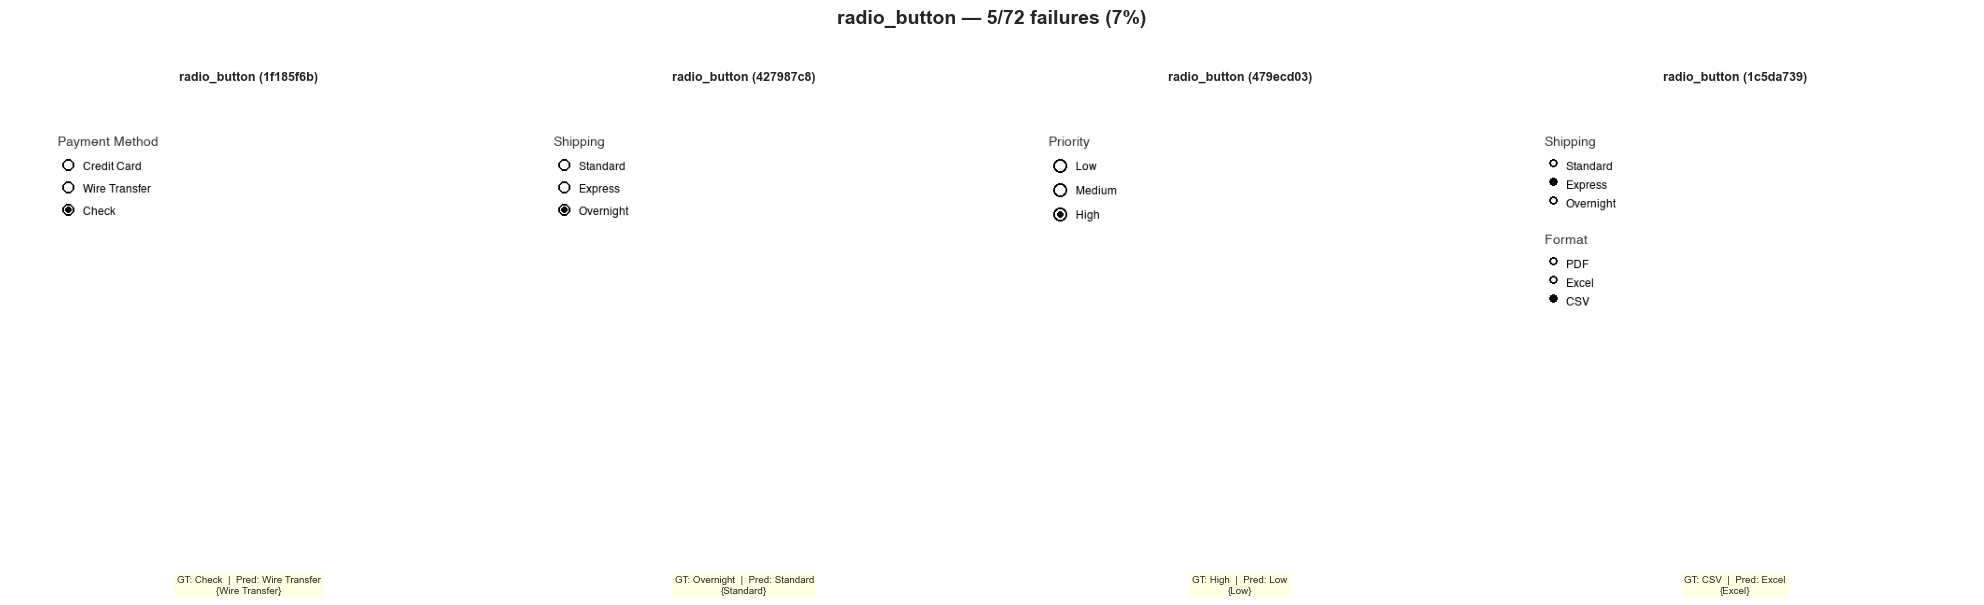

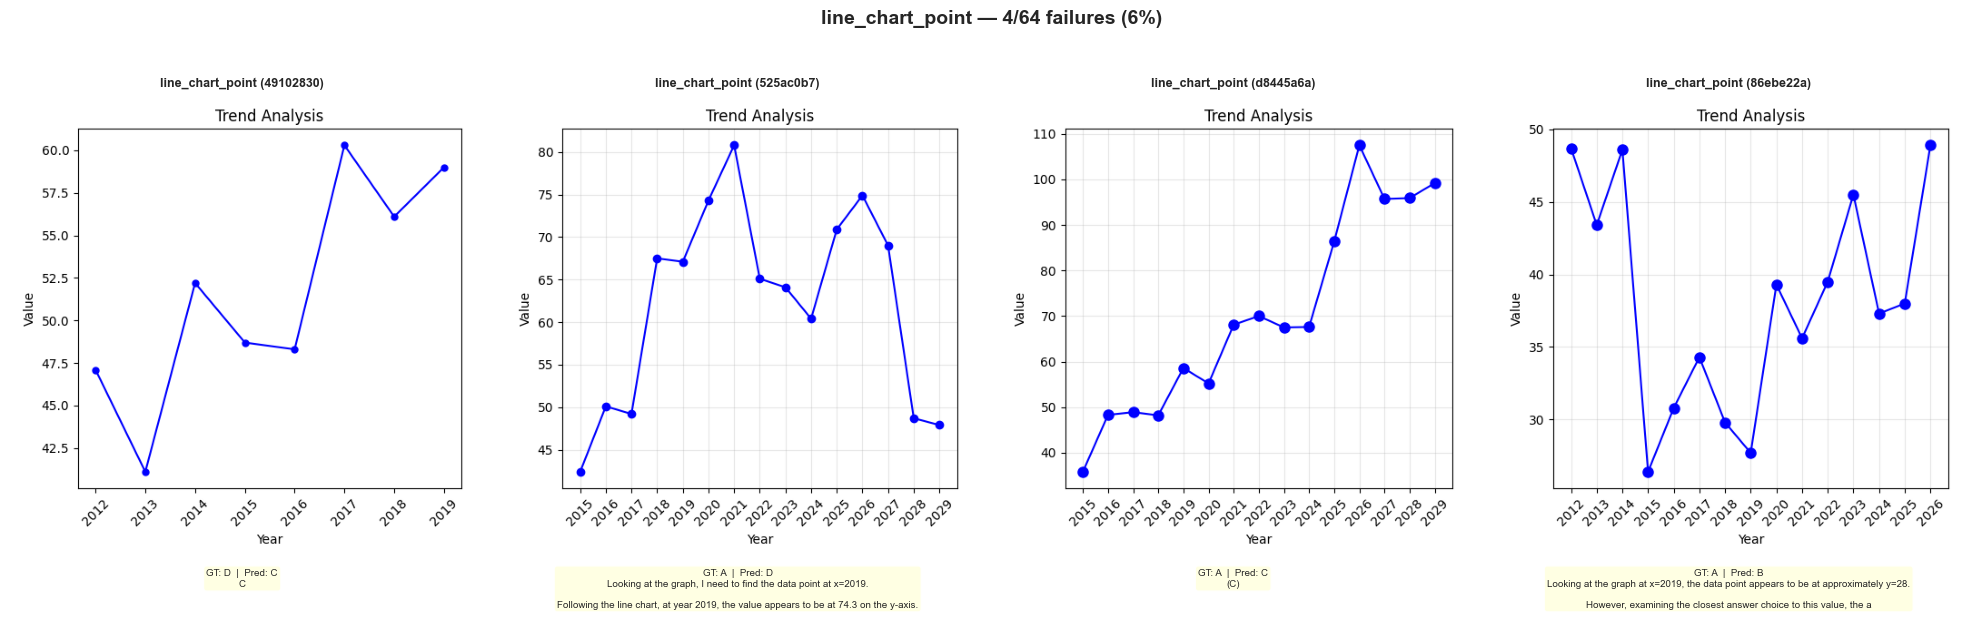

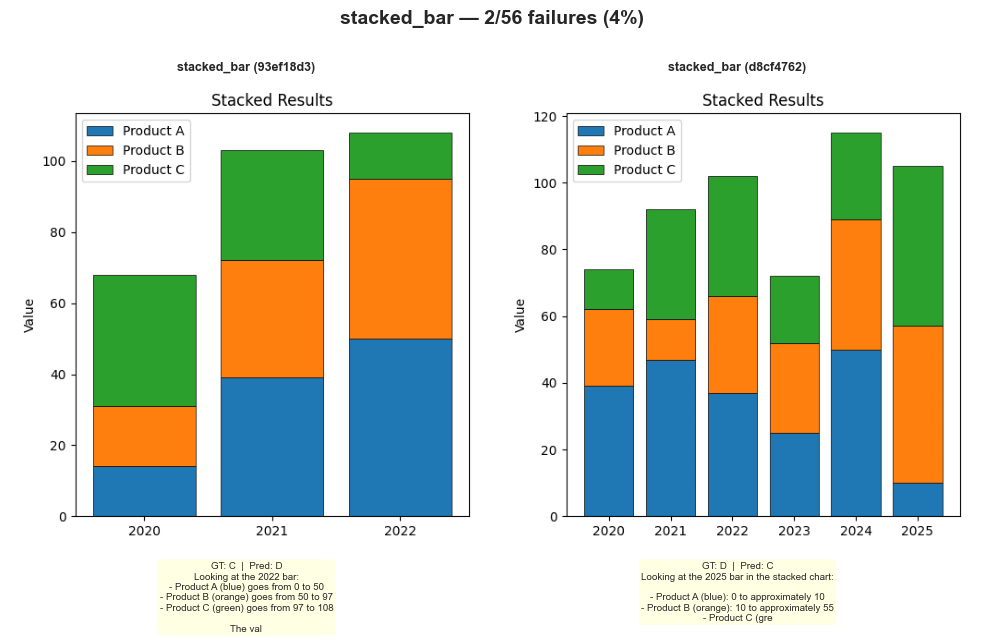

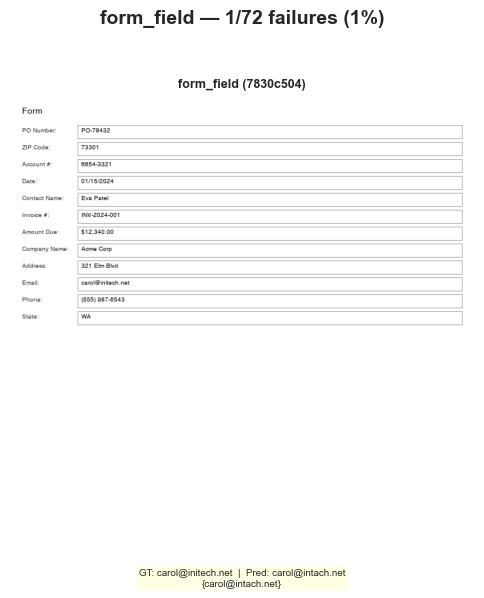

In [28]:
# Show top 4 failures per task, sorted by failure rate (worst first)
task_fail_rates = failures.groupby("task_name").size().reset_index(name="n_fail")
task_totals = df.groupby("task_name").size().reset_index(name="n_total")
task_fail_rates = task_fail_rates.merge(task_totals)
task_fail_rates["fail_rate"] = task_fail_rates["n_fail"] / task_fail_rates["n_total"]
task_fail_rates = task_fail_rates.sort_values("fail_rate", ascending=False)

for _, row in task_fail_rates.iterrows():
    task = row["task_name"]
    task_fails = failures[failures["task_name"] == task]
    if len(task_fails) == 0:
        continue
    show_failures(
        task_fails,
        title=f"{task} — {row['n_fail']}/{row['n_total']} failures ({row['fail_rate']:.0%})",
        n=4,
    )